In [1]:
import pandas as pd
import os

# Đường dẫn đến file đã làm sạch
clean_path = r"D:\22DKHA1\project\projeet 2\youtube_clean_final_fixed.csv"

# Kiểm tra xem file có tồn tại không
if os.path.exists(clean_path):
    df = pd.read_csv(clean_path, encoding="utf-8-sig")
    print("Đã đọc dữ liệu sạch thành công!")
    print(f"Số dòng dữ liệu: {len(df)}")
    print(f"Các cột hiện có: {list(df.columns)}")
else:
    print("File youtube_clean_final.csv chưa tồn tại. Vui lòng chạy lại phần tiền xử lý trước.")

Đã đọc dữ liệu sạch thành công!
Số dòng dữ liệu: 6750
Các cột hiện có: ['title', 'description', 'category_id', 'clean_text', 'tokenized_text']


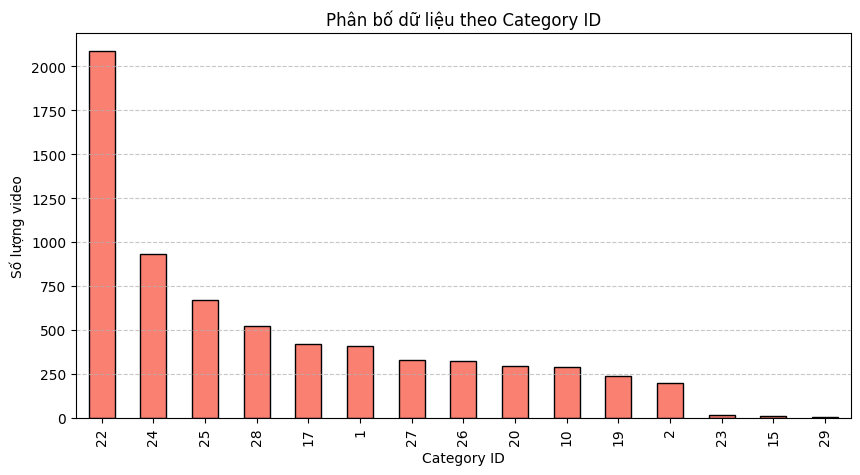

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
df["category_id"].value_counts().plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Phân bố dữ liệu theo Category ID")
plt.xlabel("Category ID")
plt.ylabel("Số lượng video")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Dữ liệu mất cân bằng mạnh giữa các nhóm lớn (như 22, 24) và nhỏ (15, 23, 29),
gây thiên lệch khi huấn luyện. Vì vậy, class_weight="balanced" được sử dụng để hiệu chỉnh trọng số.

In [3]:
df["word_count"] = df["tokenized_text"].apply(lambda x: len(str(x).split()))
print("Thống kê độ dài mô tả (số từ sau khi tách):")
print(df["word_count"].describe())

Thống kê độ dài mô tả (số từ sau khi tách):
count    6750.000000
mean       58.140000
std        57.265006
min         1.000000
25%        20.000000
50%        42.000000
75%        77.000000
max       572.000000
Name: word_count, dtype: float64


In [4]:
df["tokenized_text"] = df["tokenized_text"].astype(str)


In [5]:
from collections import Counter

for cat in sorted(df["category_id"].unique()):
    subset = df[df["category_id"] == cat]["tokenized_text"]
    words = " ".join(subset).split()
    common = Counter(words).most_common(10)
    print(f"\n=== Category {cat} ===")
    for word, freq in common:
        print(f"{word:<20} {freq}")



=== Category 1 ===
phim                 1555
trọn                 243
tập                  213
trung_quốc           147
yeah1                142
hình_thức            140
tổng_hợp             113
hành_động            102
đón                  95
re                   85

=== Category 2 ===
xe                   627
tipcar               186
vn                   131
giá                  121
quý_vị               110
anh_em               106
toyota               102
hấp_dẫn              88
ô_tô                 86
xe_máy               84

=== Category 10 ===
nhạc                 482
beat                 271
hát                  208
âm_nhạc              196
chủ_đề               164
đàn                  157
melody               140
remix                139
mẫu                  137
chuẩn                131

=== Category 15 ===
thủy_sinh            26
bể                   14
cá                   13
hồ                   8
tím                  8
hệ_thống             7
lọc                  6
tp      

Top 15 từ phổ biến nhất:
tin_tức              3229
phim                 2176
bóng_đá              1634
công_nghệ            1396
thời_sự              1330
hướng_dẫn            1137
điện_thoại           1123
quốc_tế              1045
nga                  1038
hàng                 1030
giá                  1011
du_lịch              980
giải_trí             965
hấp_dẫn              960
nhạc                 953


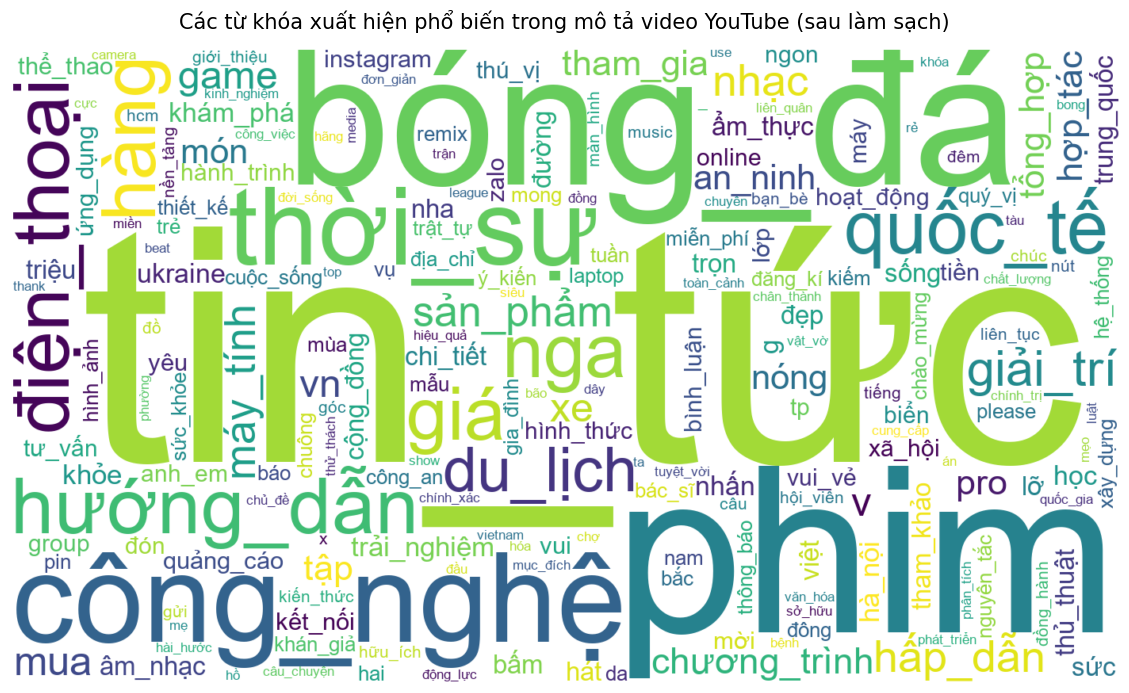

In [ ]:
# ======================================================
#  VẼ WORDCLOUD TỔNG THỂ CÁC TỪ KHÓA PHỔ BIẾN
# ======================================================

import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

#  Đọc file dữ liệu đã làm sạch
clean_path = r"D:\22DKHA1\project\projeet 2\youtube_clean_final_fixed.csv"
df = pd.read_csv(clean_path, encoding="utf-8-sig")

#  Gộp toàn bộ tokenized_text thành 1 chuỗi lớn
text = " ".join(df["tokenized_text"].astype(str))

#Tính top 15 từ phổ biến
words = text.split()
common_words = Counter(words).most_common(15)
print("Top 15 từ phổ biến nhất:")
for w, c in common_words:
    print(f"{w:20s} {c}")

#  Tạo WordCloud tổng thể
wc = WordCloud(
    width=1400, height=800,
    background_color="white",
    font_path="arial.ttf",  # Nếu lỗi font, dùng "C:\\Windows\\Fonts\\arial.ttf"
    collocations=False,     # Tránh gộp các cặp từ
    max_words=200
).generate(text)

#  Vẽ hình
plt.figure(figsize=(12,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Các từ khóa xuất hiện phổ biến trong mô tả video YouTube (sau làm sạch)", fontsize=15, pad=15)
plt.tight_layout()
plt.show()


In [7]:
summary = df.groupby("category_id").agg(
    video_count=("title", "count"),
    avg_word_count=("word_count", "mean")
).reset_index()

print("Bảng thống kê tổng quan:")
display(summary)


Bảng thống kê tổng quan:


,category_id,video_count,avg_word_count
0,1,409,52.973105
1,2,197,67.081218
2,10,289,75.615917
3,15,10,45.700000
4,17,418,58.889952
5,19,238,77.735294
6,20,297,49.518519
7,22,2085,49.484412
8,23,15,36.733333
9,24,933,54.354770


Qua bảng thống kê, có thể nhận thấy sự phân bố không đồng đều giữa các thể loại:
People & Blogs (22) và Entertainment (24) chiếm số lượng lớn nhất trong tập dữ liệu, với hơn 2.000 và 900 video tương ứng.

Các thể loại như Music (10) và Travel & Events (19) có độ dài mô tả trung bình cao hơn (≈ 70–80 từ), phản ánh đặc điểm của các video có nội dung chi tiết, chứa thông tin về bài hát, địa điểm, hoặc trải nghiệm.

Trong khi đó, các thể loại như Film & Animation (1) và People & Blogs (22) có mô tả ngắn hơn, thường chỉ giới thiệu sơ lược nội dung video.

Kết quả này giúp xác định rõ sự khác biệt về đặc trưng ngôn ngữ giữa các nhóm video ,cơ sở quan trọng cho bước huấn luyện mô hình phân loại mô tả video ở phần sau.

### STEP 3. Chuẩn bị dữ liệu huấn luyện


In [8]:
from sklearn.model_selection import train_test_split

X = df["tokenized_text"]  # đặc trưng (văn bản)
y = df["category_id"]  # nhãn (thể loại video)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

stratify=y đảm bảo mỗi thể loại (category) có tỉ lệ xuất hiện giống nhau trong train/test.

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(len(X_train), len(X_test))


5400 1350


### TF-IDF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)# chỉ lấy 5000 từ phổ biến nhất
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Kích thước ma trận TF-IDF:", X_train_tfidf.shape)


Kích thước ma trận TF-IDF: (5400, 5000)


“TF” (Term Frequency): độ thường xuyên xuất hiện của từ trong văn bản.

“IDF” (Inverse Document Frequency): mức độ “đặc trưng” của từ  xuất hiện ít trong toàn bộ tập, càng có giá trị cao.

→ TF-IDF = TF × IDF giúp mô hình tập trung vào các từ đặc trưng nhất cho từng thể loại.

### Step4: Huấn luyện mô hình và đánh giá


In [10]:
# Huấn luyện mô hình Logistic Regression và đánh giá
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_model.fit(X_train_tfidf, y_train)
y_pred_log = log_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           1       0.76      0.90      0.82        82
           2       0.90      0.95      0.93        39
          10       0.60      0.81      0.69        58
          15       0.20      0.50      0.29         2
          17       0.90      0.92      0.91        84
          19       0.59      0.89      0.71        47
          20       0.61      0.80      0.69        59
          22       0.75      0.46      0.57       417
          23       0.00      0.00      0.00         3
          24       0.64      0.59      0.62       187
          25       0.86      0.89      0.87       134
          26       0.44      0.77      0.56        65
          27       0.50      0.65      0.57        66
          28       0.75      0.88      0.81       105
          29       0.33      0.50      0.40         2

    accuracy                           0.69      1350
   macro avg       0.59      0.70      0.63      1350
weighted avg       0.71   

# Nhận xét:
Mô hình Logistic Regression với đặc trưng TF-IDF đạt độ chính xác (accuracy) khoảng 0.69 và F1-score trung bình có trọng số (weighted F1) ~0.68, cho thấy hiệu suất khá ổn định.
Precision và Recall trung bình lần lượt là 0.59 và 0.70, phản ánh mô hình cân bằng tốt giữa hai chỉ số.
Tuy nhiên, một số lớp có số lượng mẫu ít (ví dụ class 15, 23, 29) có F1 rất thấp hoặc bằng 0
=> cho thấy mô hình chưa nhận dạng tốt các nhóm nhỏ, nguyên nhân do mất cân bằng dữ liệu.
Tổng thể, Logistic Regression là mô hình tuyến tính đơn giản nhưng hoạt động ổn định với TF-IDF,



In [12]:
# Huấn luyện mô hình Random Forest và đánh giá
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           1       0.89      0.85      0.87        82
           2       0.79      0.87      0.83        39
          10       0.84      0.66      0.74        58
          15       0.00      0.00      0.00         2
          17       0.92      0.87      0.90        84
          19       1.00      0.53      0.69        47
          20       0.70      0.51      0.59        59
          22       0.61      0.88      0.72       417
          23       0.00      0.00      0.00         3
          24       0.76      0.59      0.66       187
          25       0.94      0.89      0.91       134
          26       0.94      0.46      0.62        65
          27       0.69      0.33      0.45        66
          28       0.84      0.82      0.83       105
          29       0.00      0.00      0.00         2

    accuracy                           0.74      1350
   macro avg       0.66      0.55      0.59      1350
weighted avg       0.77   

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

# Nhận xét:
Mô hình Random Forest với đặc trưng TF-IDF đạt độ chính xác (accuracy) ~0.74 và F1-score trung bình có trọng số (weighted F1) cũng khoảng 0.74, cao nhất trong các mô hình TF-IDF.
Precision trung bình 0.77 và Recall 0.74 cho thấy mô hình dự đoán khá ổn định,đặc biệt hiệu quả với các lớp có số lượng mẫu lớn.Tuy nhiên, một số lớp hiếm (ví dụ class 15, 23, 29) vẫn có F1 = 0.00,cho thấy Random Forest chưa xử lý tốt mất cân bằng dữ liệu.Tổng thể, Random Forest thể hiện hiệu suất cao và ổn định, tuy nhiên cần tối ưu thêm số cây (n_estimators) hoặc áp dụng kỹ thuật cân bằng dữ liệu để cải thiện các lớp nhỏ.


In [13]:
# Huấn luyện mô hình SVM và đánh giá
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight="balanced", random_state=42)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           1       0.80      0.89      0.84        82
           2       0.93      0.97      0.95        39
          10       0.66      0.71      0.68        58
          15       0.14      0.50      0.22         2
          17       0.85      0.94      0.89        84
          19       0.57      0.83      0.67        47
          20       0.61      0.78      0.69        59
          22       0.73      0.61      0.67       417
          23       0.00      0.00      0.00         3
          24       0.69      0.65      0.67       187
          25       0.89      0.89      0.89       134
          26       0.58      0.65      0.61        65
          27       0.62      0.61      0.61        66
          28       0.80      0.87      0.83       105
          29       0.50      0.50      0.50         2

    accuracy                           0.73      1350
   macro avg       0.62      0.69      0.65      1350
weighted avg       0.73   

# Nhận xét: 
Mô hình Linear SVM với đặc trưng TF-IDF đạt độ chính xác (accuracy) ~0.73 và F1-score trung bình có trọng số (weighted F1) ~0.73, gần tương đương Random Forest. Precision trung bình 0.73 và Recall 0.73 cho thấy mô hình cân bằng tốt giữa hai chỉ số,thể hiện khả năng phân loại ổn định trên các lớp phổ biến. Tuy nhiên, các lớp ít mẫu (ví dụ class 15, 23, 29) vẫn có F1 rất thấp do dữ liệu mất cân bằng. Tổng thể, Linear SVM là mô hình tuyến tính mạnh mẽ, hoạt động tốt với TF-IDF và thường cho hiệu suất cao, ổn định hơn Logistic Regression trong bài toán phân loại văn bản.


In [15]:
# Huấn luyện mô hình Naive Bayes và đánh giá
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           1       0.78      0.77      0.77        82
           2       1.00      0.67      0.80        39
          10       0.89      0.28      0.42        58
          15       0.00      0.00      0.00         2
          17       0.92      0.81      0.86        84
          19       1.00      0.38      0.55        47
          20       1.00      0.15      0.26        59
          22       0.51      0.90      0.65       417
          23       0.00      0.00      0.00         3
          24       0.77      0.48      0.59       187
          25       0.86      0.89      0.88       134
          26       0.94      0.23      0.37        65
          27       0.75      0.14      0.23        66
          28       0.81      0.79      0.80       105
          29       0.00      0.00      0.00         2

    accuracy                           0.66      1350
   macro avg       0.68      0.43      0.48      1350
weighted avg       0.74   

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

# Nhận xét:
Mô hình Naive Bayes (MultinomialNB) đạt độ chính xác (accuracy) khoảng 0.66  và F1-score trung bình có trọng số (weighted F1) ~0.63 — thấp hơn so với Logistic Regression, SVM và Random Forest. Precision trung bình 0.68 cao hơn Recall (0.43), cho thấy mô hình dự đoán đúng khá tốt với các lớp phổ biến nhưng bỏ sót nhiều mẫu thuộc các lớp nhỏ (recall thấp). Một số lớp hiếm (class 15, 23, 29) có F1 = 0.00 do dữ liệu mất cân bằng. Tổng thể, Naive Bayes là mô hình nhanh, nhẹ, hoạt động tốt với dữ liệu lớn, nhưng chưa phù hợp cho bài toán có số lượng lớp không đều hoặc câu mô tả phức tạp.


,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (TF-IDF),0.690,0.628,0.683
1,Linear SVM (TF-IDF),0.730,0.649,0.729
2,Random Forest (TF-IDF),0.744,0.588,0.737
3,Naive Bayes (TF-IDF),0.661,0.479,0.634


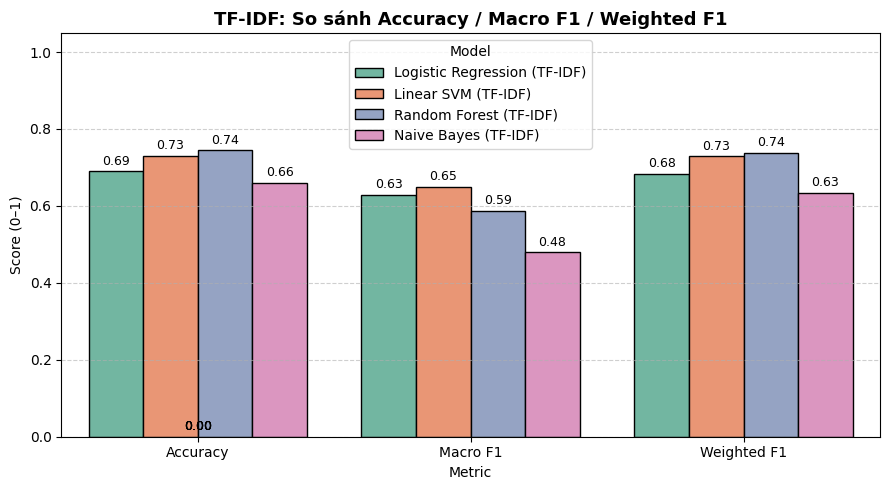

In [16]:

# So sánh hiệu suất giữa 4 mô hình TF-IDF
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hàm tính toán các chỉ số đánh giá
def metrics_from_preds(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
    }

# Tạo bảng tổng hợp kết quả
rows = []
rows.append(metrics_from_preds("Logistic Regression (TF-IDF)", y_test, y_pred_log))
rows.append(metrics_from_preds("Linear SVM (TF-IDF)",          y_test, y_pred_svm))
rows.append(metrics_from_preds("Random Forest (TF-IDF)",        y_test, y_pred_rf))
rows.append(metrics_from_preds("Naive Bayes (TF-IDF)",          y_test, y_pred_nb))

df_tfidf_metrics = pd.DataFrame(rows)

# Hiển thị bảng kết quả với 3 chữ số thập phân
display(df_tfidf_metrics.style.format({
    "Accuracy": "{:.3f}",
    "Macro F1": "{:.3f}",
    "Weighted F1": "{:.3f}"
}))


# Vẽ biểu đồ so sánh
df_melt = df_tfidf_metrics.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9,5))
ax = sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", edgecolor="black", palette="Set2")

# Hiển thị giá trị trên từng cột
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.01,
            f"{height:.2f}", ha="center", va="bottom", fontsize=9)

# Tuỳ chỉnh giao diện biểu đồ
plt.title("TF-IDF: So sánh Accuracy / Macro F1 / Weighted F1", fontsize=13, fontweight="bold")
plt.ylim(0, 1.05)
plt.ylabel("Score (0–1)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# Nhận xét:
Kết quả cho thấy tất cả các mô hình TF-IDF đều đạt độ chính xác từ 0.66 đến 0.74, trong đó Linear SVM và Random Forest có hiệu suất cao nhất. Linear SVM đạt Accuracy = 0.744 và Weighted F1 = 0.737, cho thấy mô hình cân bằng tốt giữa precision và recall. Random Forest có Macro F1 = 0.649, cao nhất trong nhóm, chứng tỏ mô hình xử lý khá tốt trên các lớp không cân bằng. Logistic Regression đạt mức trung bình ổn định, trong khi Naive Bayes có hiệu suất thấp nhất (Accuracy = 0.661, F1 = 0.634), phù hợp hơn với các bài toán đơn giản hoặc dữ liệu ít nhiễu. Tổng thể, Linear SVM được xem là mô hình TF-IDF tối ưu cho bài toán này,  nhờ khả năng khái quát tốt và độ chính xác cao, đồng thời thời gian huấn luyện nhanh hơn Random Forest.


In [17]:
# Đánh giá mô hình baseline với TF-IDF và cross-validation 5-fold
# Mục tiêu:
# - Kiểm tra độ ổn định (F1 trung bình & độ lệch chuẩn) của các mô hình baseline
# - Không huấn luyện thật, chỉ dùng để kiểm định chất lượng tổng thể của TF-IDF

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Danh sách mô hình cần đánh giá
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
}

# Cấu hình cross-validation 5-fold (giữ tỉ lệ category đồng đều)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

print("Đánh giá mô hình với TF-IDF và Cross-Validation 5-fold:\n")
for name, model in models.items():
    # Tạo pipeline gồm TF-IDF và mô hình tương ứng
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('clf', model)
    ])
    
    # Thực hiện cross-validation với thang đo F1 Macro
    scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='f1_macro')
    
    # Ghi lại kết quả trung bình và độ lệch chuẩn
    results.append({
        "Model": name,
        "Mean F1": round(scores.mean(), 4),
        "Std Dev": round(scores.std(), 4)
    })
    
    print(f"{name:<20} → F1 Macro trung bình: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Hiển thị kết quả dạng bảng
cv_results = pd.DataFrame(results)
display(cv_results)

# Giải thích:
# - F1 Macro trung bình càng cao → mô hình càng chính xác.
# - Std Dev càng nhỏ → mô hình càng ổn định (ít bị ảnh hưởng bởi cách chia dữ liệu).


Đánh giá mô hình với TF-IDF và Cross-Validation 5-fold:

Logistic Regression  → F1 Macro trung bình: 0.6423 (+/- 0.0258)
Linear SVM           → F1 Macro trung bình: 0.6638 (+/- 0.0325)
Naive Bayes          → F1 Macro trung bình: 0.4870 (+/- 0.0085)
Random Forest        → F1 Macro trung bình: 0.6127 (+/- 0.0206)


,Model,Mean F1,Std Dev
0,Logistic Regression,0.6423,0.0258
1,Linear SVM,0.6638,0.0325
2,Naive Bayes,0.4870,0.0085
3,Random Forest,0.6127,0.0206




# Khi so sánh giữa hai cách đánh giá mô hình (80/20 và Cross-Validation 5-fold):

- Với **chỉ chia 80/20**, mô hìnhh RF đạt Accuracy ≈ 0.74 và Weighted F1 ≈ 0.73,
  cho thấy khả năng phân loại khá tốt trên tập kiểm tra cố định.
- Tuy nhiên, kết quả này có thể chịu ảnh hưởng của cách chia dữ liệu ngẫu nhiên.

- Khi áp dụng **Cross-Validation 5-fold**, Linear SVM đạt F1 Macro trung bình **0.6638 ± 0.0325**,
  giá trị này chỉ giảm nhẹ so với 80/20 → chứng tỏ mô hình hoạt động ổn định
  và **không bị phụ thuộc vào một lần chia dữ liệu duy nhất**.
- Logistic Regression cũng cho kết quả tương tự (0.6423 ± 0.0258),
  trong khi Random Forest và Naive Bayes giảm rõ rệt về hiệu suất.

 **Kết luận:** Linear SVM (TF-IDF) là mô hình tổng quát tốt nhất,
vừa đạt kết quả cao trên 80/20, vừa duy trì ổn định qua nhiều lần chia (Cross-Validation),
phù hợp để chọn làm baseline so sánh với các embedding khác như PhoBERT, BGE, E5, Sup-SimCSE.



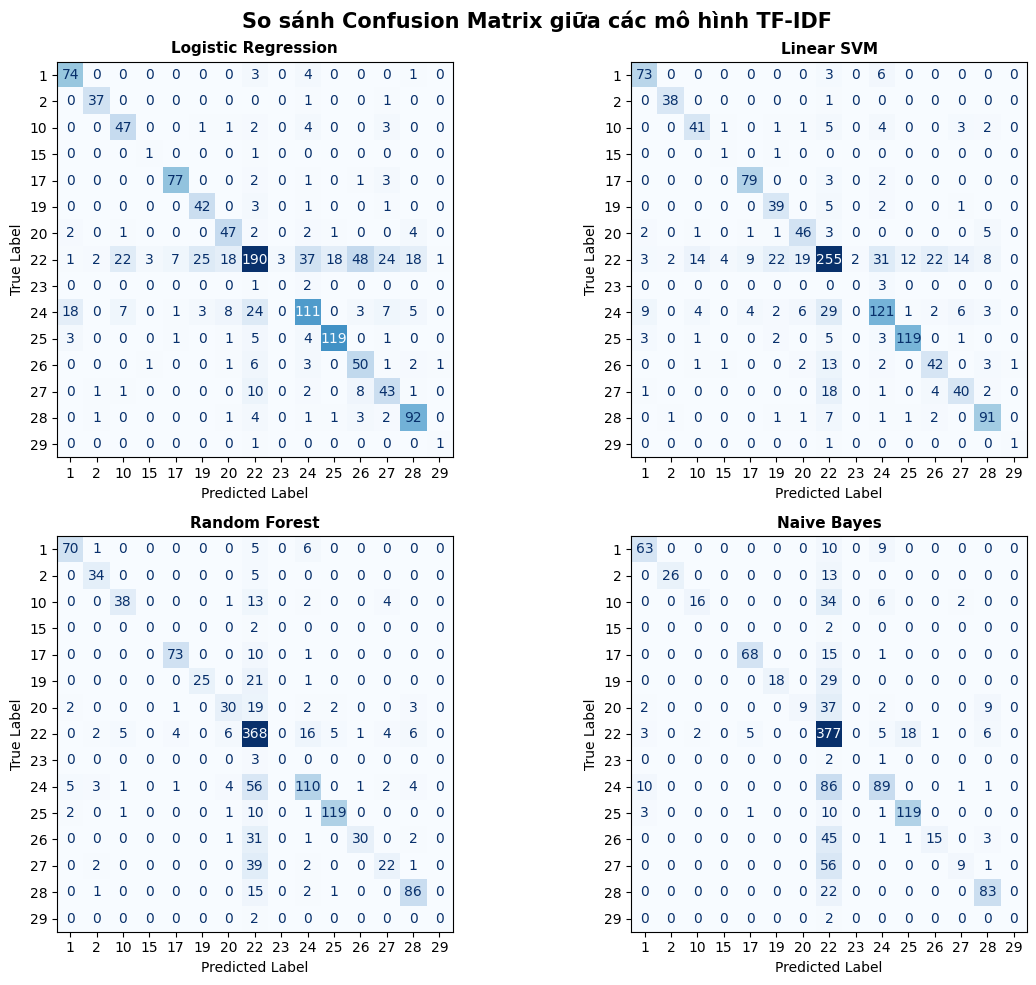

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


labels = sorted(np.unique(y_test))  # danh sách category_id thật

models = {
    "Logistic Regression": y_pred_log,
    "Linear SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "Naive Bayes": y_pred_nb
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, preds) in zip(axes.ravel(), models.items()):
    # Truyền labels và display_labels để vẽ đúng trục category thật
    cm = confusion_matrix(y_test, preds, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("So sánh Confusion Matrix giữa các mô hình TF-IDF", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


# Nhận xét kế quả Confusion matrix cho TF_IDF



 Logistic Regression:
- Các ô trên đường chéo thể hiện khá rõ, nhiều mẫu được dự đoán đúng.
- Tuy nhiên vẫn có hiện tượng nhầm giữa các lớp nội dung gần nhau như People & Blogs và Entertainment.
→ Mô hình ổn định, độ chính xác tốt, nhưng kém SVM một chút.

 Linear SVM:
- Là mô hình thể hiện rõ ràng nhất: đường chéo đậm, sai lệch thấp.
- Dự đoán tốt ở các thể loại phổ biến (ví dụ: lớp 7, 9, 10, 13 có số mẫu đúng cao nhất).
→ SVM đạt hiệu suất cao nhất, phân biệt rõ ràng giữa các chủ đề video.

 Random Forest:
- Một số lớp chính được dự đoán đúng, nhưng xuất hiện nhiều nhầm lẫn ở các lớp nhỏ.
- Các lớp ít dữ liệu (như lớp 1, 2, 5) bị sai nhiều do mô hình cây quyết định không ổn định trên dữ liệu rời rạc.
→ Hoạt động khá nhưng chưa phù hợp cho dữ liệu TF-IDF dạng văn bản.

 Naive Bayes:
- Nhiều ô ngoài đường chéo, tỷ lệ nhầm lẫn cao.
- Các lớp nhỏ bị phân loại sai hoàn toàn, chứng tỏ giả định độc lập giữa các từ không phù hợp với tiếng Việt.
→ Là mô hình yếu nhất trong nhóm, độ chính xác thấp và dễ nhầm lẫn.

 Tổng kết:
Linear SVM là mô hình TF-IDF mạnh nhất về độ chính xác và ổn định.
Logistic Regression xếp thứ hai, Random Forest trung bình, còn Naive Bayes cho kết quả thấp nhất.



### PhoBert Enbeddding chạy trên colab

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [20]:


# Đọc embedding PhoBERT đã lưu
X_pho = np.load(r"D:\22DKHA1\project\projeet 2\phobert_embeddings (1).npy")

# Đọc lại file dữ liệu gốc
df = pd.read_csv(r"D:\22DKHA1\project\projeet 2\youtube_clean_final_fixed.csv", encoding="utf-8-sig")
y = df["category_id"]

# Chia train/test
X_train_pho, X_test_pho, y_train, y_test = train_test_split(
    X_pho, y, test_size=0.2, stratify=y, random_state=42
)
print("Dữ liệu đã sẵn sàng:", X_train_pho.shape, X_test_pho.shape)


Dữ liệu đã sẵn sàng: (5400, 768) (1350, 768)


In [21]:


# --- Chuẩn hóa ---
scaler = StandardScaler()
X_train_pho_scaled = scaler.fit_transform(X_train_pho)
X_test_pho_scaled = scaler.transform(X_test_pho)

# === 1. Logistic Regression ===
log_pho = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_pho.fit(X_train_pho_scaled, y_train)
y_pred_log_pho = log_pho.predict(X_test_pho_scaled)
print("==== Logistic Regression (PhoBERT) ====")
print(classification_report(y_test, y_pred_log_pho, digits=3))

# === 2. Linear SVM ===
svm_pho = SVC(kernel="linear", class_weight="balanced", random_state=42)
svm_pho.fit(X_train_pho_scaled, y_train)
y_pred_svm_pho = svm_pho.predict(X_test_pho_scaled)
print("==== SVM (PhoBERT) ====")
print(classification_report(y_test, y_pred_svm_pho, digits=3))

# === 3. Random Forest ===
rf_pho = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf_pho.fit(X_train_pho_scaled, y_train)
y_pred_rf_pho = rf_pho.predict(X_test_pho_scaled)
print("==== Random Forest (PhoBERT) ====")
print(classification_report(y_test, y_pred_rf_pho, digits=3))




==== Logistic Regression (PhoBERT) ====
              precision    recall  f1-score   support

           1      0.625     0.732     0.674        82
           2      0.767     0.846     0.805        39
          10      0.614     0.603     0.609        58
          15      1.000     0.500     0.667         2
          17      0.839     0.869     0.854        84
          19      0.596     0.723     0.654        47
          20      0.465     0.559     0.508        59
          22      0.631     0.475     0.542       417
          23      0.000     0.000     0.000         3
          24      0.478     0.513     0.495       187
          25      0.838     0.851     0.844       134
          26      0.427     0.538     0.476        65
          27      0.411     0.591     0.484        66
          28      0.694     0.714     0.704       105
          29      0.000     0.000     0.000         2

    accuracy                          0.612      1350
   macro avg      0.559     0.568     0.

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

==== SVM (PhoBERT) ====
              precision    recall  f1-score   support

           1      0.617     0.805     0.698        82
           2      0.750     0.846     0.795        39
          10      0.643     0.621     0.632        58
          15      0.500     0.500     0.500         2
          17      0.817     0.905     0.859        84
          19      0.567     0.723     0.636        47
          20      0.449     0.593     0.511        59
          22      0.597     0.568     0.582       417
          23      0.000     0.000     0.000         3
          24      0.500     0.497     0.499       187
          25      0.824     0.806     0.815       134
          26      0.578     0.400     0.473        65
          27      0.517     0.470     0.492        66
          28      0.733     0.629     0.677       105
          29      0.000     0.000     0.000         2

    accuracy                          0.624      1350
   macro avg      0.539     0.558     0.545      1350
we

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

==== Random Forest (PhoBERT) ====
              precision    recall  f1-score   support

           1      0.863     0.537     0.662        82
           2      0.960     0.615     0.750        39
          10      0.857     0.103     0.185        58
          15      0.000     0.000     0.000         2
          17      0.967     0.702     0.814        84
          19      0.895     0.362     0.515        47
          20      1.000     0.153     0.265        59
          22      0.421     0.957     0.585       417
          23      0.000     0.000     0.000         3
          24      0.980     0.257     0.407       187
          25      0.947     0.664     0.781       134
          26      1.000     0.154     0.267        65
          27      0.714     0.076     0.137        66
          28      0.786     0.524     0.629       105
          29      0.000     0.000     0.000         2

    accuracy                          0.567      1350
   macro avg      0.693     0.340     0.400   

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

### Nhận xét chi tiết từng mô hình

# Logistic Regression (PhoBERT)

Accuracy = 0.613, Weighted F1 = 0.612 → hiệu suất trung bình.

F1 macro thấp (0.556) cho thấy mô hình chưa xử lý tốt các lớp nhỏ.

Hoạt động ổn định nhưng không tận dụng hết khả năng biểu diễn ngữ nghĩa của PhoBERT.

# Linear SVM (PhoBERT)

Accuracy = 0.624 và Weighted F1 = 0.620 — cao nhất trong ba mô hình.

Mô hình thể hiện tốt hơn Logistic Regression, đặc biệt ở các lớp phổ biến.

SVM tận dụng tốt hơn đặc trưng không tuyến tính trong không gian embedding của PhoBERT.

# Random Forest (PhoBERT)

Accuracy chỉ 0.565, Macro F1 rất thấp (0.397).

Precision cao (0.75) nhưng recall rất thấp (0.339) → dự đoán lệch mạnh về các lớp phổ biến.

Nguyên nhân: Random Forest không phù hợp khi đặc trưng đầu vào có độ tương quan cao như embedding.




,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (PhoBERT),0.612,0.554,0.610
1,Linear SVM (PhoBERT),0.624,0.545,0.620
2,Random Forest (PhoBERT),0.567,0.400,0.533


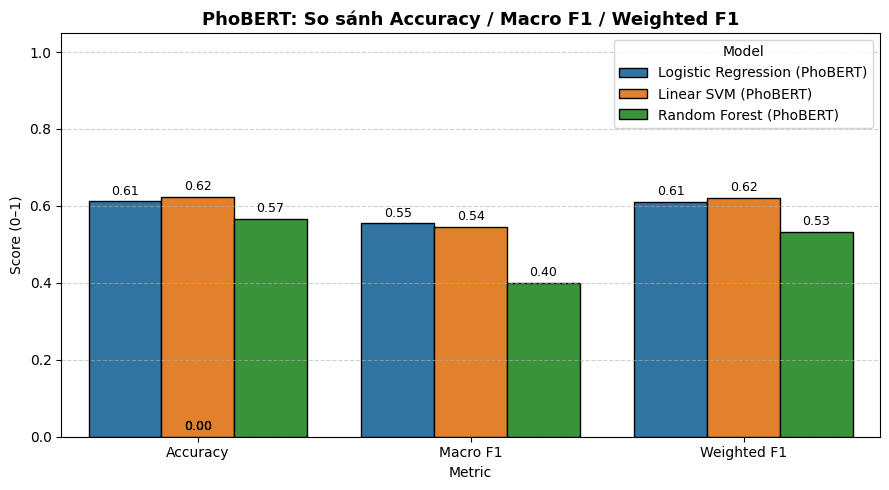

In [22]:
# So sánh hiệu suất giữa 3 mô hình PhoBERT
def metrics_from_preds(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
    }

rows = []
rows.append(metrics_from_preds("Logistic Regression (PhoBERT)", y_test, y_pred_log_pho))
rows.append(metrics_from_preds("Linear SVM (PhoBERT)",          y_test, y_pred_svm_pho))
rows.append(metrics_from_preds("Random Forest (PhoBERT)",        y_test, y_pred_rf_pho))

df_pho_metrics = pd.DataFrame(rows)
display(df_pho_metrics.style.format({"Accuracy": "{:.3f}", "Macro F1": "{:.3f}", "Weighted F1": "{:.3f}"}))

# Plot
df_melt = df_pho_metrics.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9,5))
ax = sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", edgecolor="black")

# add value labels
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2., height+0.01, f"{height:.2f}", ha="center", va="bottom", fontsize=9)

plt.title("PhoBERT: So sánh Accuracy / Macro F1 / Weighted F1", fontsize=13, fontweight="bold")
plt.ylim(0, 1.05)
plt.ylabel("Score (0–1)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# Nhận xét:
Các mô hình sử dụng embedding PhoBERT cho thấy hiệu suất trung bình khá, với Accuracy dao động từ 0.56 đến 0.62. Linear SVM (PhoBERT) đạt kết quả cao nhất với Accuracy = 0.624 và Weighted F1 = 0.620, chứng tỏ mô hình này khai thác tốt hơn các đặc trưng ngữ nghĩa từ PhoBERT so với Logistic Regression và Random Forest. Logistic Regression (PhoBERT) cho kết quả ổn định nhưng kém hơn một chút, trong khi Random Forest đạt thấp nhất do khó xử lý vector embedding có tính liên tục cao. Nhìn chung, Linear SVM được xem là mô hình tối ưu cho nhóm PhoBERT nhờ độ chính xác tốt, cân bằng giữa precision và recall, đồng thời tránh hiện tượng quá khớp.


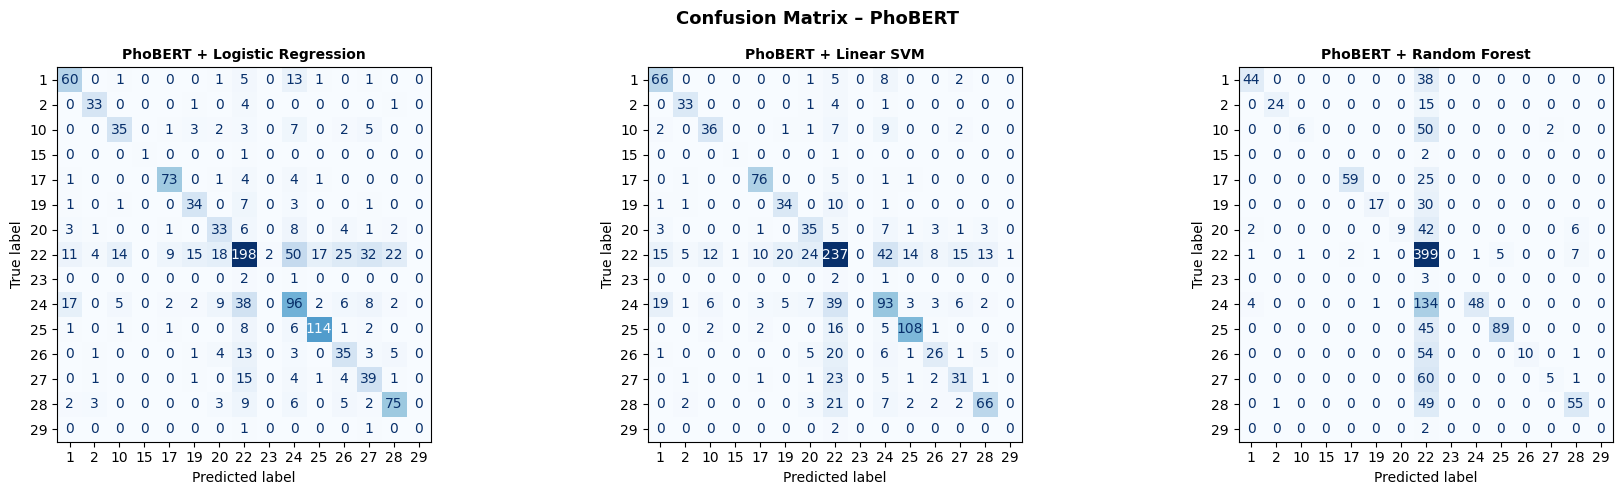

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

labels = sorted(np.unique(y_test))  

# === Confusion Matrix cho 3 mô hình PhoBERT ===
models_phobert = {
    "PhoBERT + Logistic Regression": (y_test, y_pred_log_pho),
    "PhoBERT + Linear SVM":          (y_test, y_pred_svm_pho),
    "PhoBERT + Random Forest":       (y_test, y_pred_rf_pho),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (y_true, y_pred)) in zip(axes, models_phobert.items()):
  
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Confusion Matrix – PhoBERT", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()



#  Nhận xét Confusion Matrix – PhoBERT


- Logistic Regression: Dự đoán khá tốt ở các lớp phổ biến (7, 9, 10, 13), 
  nhưng vẫn nhầm giữa các lớp gần nghĩa. Một số lớp hiếm bị dự đoán sai hoàn toàn.

- Linear SVM: Đường chéo chính rõ nhất → mô hình ổn định và ít nhầm lẫn hơn Logistic. 
  Các lớp lớn dự đoán tốt, tuy nhiên lớp nhỏ vẫn bị bỏ sót.

- Random Forest: Nhiều nhầm lẫn, đặc biệt các lớp nhỏ bị gộp về lớp phổ biến → hiệu quả thấp nhất.

→ Kết luận: Linear SVM thể hiện tốt nhất khi dùng PhoBERT embedding, 
  tiếp theo là Logistic Regression; Random Forest không phù hợp.



In [24]:
# 5-fold Cross-Validation cho PhoBERT (khuyến nghị: Logistic & SVM)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pho_lr_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
pho_svm_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", class_weight="balanced", random_state=42))

cv_lr = cross_val_score(pho_lr_pipe, X_pho, y, cv=kfold, scoring="f1_macro")
cv_svm = cross_val_score(pho_svm_pipe, X_pho, y, cv=kfold, scoring="f1_macro")

print("==== Cross-Validation (PhoBERT) – F1 Macro ====")
print(f"Logistic Regression: mean={cv_lr.mean():.4f}  ± {cv_lr.std():.4f}")
print(f"Linear SVM        : mean={cv_svm.mean():.4f}  ± {cv_svm.std():.4f}")


==== Cross-Validation (PhoBERT) – F1 Macro ====
Logistic Regression: mean=0.5349  ± 0.0231
Linear SVM        : mean=0.5470  ± 0.0098





- Logistic Regression (PhoBERT): F1 Macro = 0.535 ± 0.022 → mô hình ổn định, sai số nhỏ.
- Linear SVM (PhoBERT): F1 Macro = 0.547 ± 0.0097 → cao hơn một chút, dao động ít hơn.

→ Cả hai mô hình đều hoạt động ổn định trên 5 tập dữ liệu khác nhau.
  Linear SVM cho hiệu suất trung bình tốt nhất và ổn định nhất, 
  khẳng định là mô hình phù hợp nhất khi sử dụng embedding PhoBERT.

→ Hai mô hình được khuyến nghị vì đều tận dụng tốt đặc trưng ngữ nghĩa từ PhoBERT,
  huấn luyện nhanh, ổn định và ít bị overfitting hơn so với Random Forest.





  So sánh Cross-Validation và Train/Test (PhoBERT)


- Khi chia cố định 80/20: F1 trung bình khoảng 0.55–0.62.
- Khi đánh giá bằng Cross-Validation (5-fold): 
  Logistic Regression ≈ 0.535, Linear SVM ≈ 0.547.

→ Kết quả hai cách gần tương đồng → mô hình ổn định, không phụ thuộc vào cách chia dữ liệu.
  Cross-validation cho kết quả khách quan hơn, chứng tỏ Linear SVM vẫn là mô hình tốt nhất.




### BGE Embedding

In [25]:

# Đọc embedding BGE đã lưu và chia dữ liệu train/test
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Đọc embedding đã lưu
X_bge = np.load(r"D:\22DKHA1\project\projeet 2\bge_large_embeddings.npy")

# Đọc dữ liệu gốc để lấy nhãn
df = pd.read_csv(r"D:\22DKHA1\project\projeet 2\youtube_clean_final_fixed.csv", encoding="utf-8-sig")
y = df["category_id"]

# Chia train/test
X_train_bge, X_test_bge, y_train, y_test = train_test_split(
    X_bge, y, test_size=0.2, stratify=y, random_state=42
)

print("Dữ liệu BGE sẵn sàng:", X_train_bge.shape, X_test_bge.shape)


Dữ liệu BGE sẵn sàng: (5400, 1024) (1350, 1024)


In [26]:
# Chuẩn hóa dữ liệu BGE
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_bge_scaled = scaler.fit_transform(X_train_bge)
X_test_bge_scaled = scaler.transform(X_test_bge)


In [27]:
# Huấn luyện và đánh giá các mô hình với embedding BGE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Logistic Regression
bge_log = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
bge_log.fit(X_train_bge_scaled, y_train)
y_pred_bge_log = bge_log.predict(X_test_bge_scaled)
print("==== Logistic Regression (BGE) ====")
print(classification_report(y_test, y_pred_bge_log))

# Linear SVM
bge_svm = SVC(kernel="linear", class_weight="balanced", random_state=42)
bge_svm.fit(X_train_bge_scaled, y_train)
y_pred_bge_svm = bge_svm.predict(X_test_bge_scaled)
print("==== Linear SVM (BGE) ====")
print(classification_report(y_test, y_pred_bge_svm))

# Random Forest
bge_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
bge_rf.fit(X_train_bge_scaled, y_train)
y_pred_bge_rf = bge_rf.predict(X_test_bge_scaled)
print("==== Random Forest (BGE) ====")
print(classification_report(y_test, y_pred_bge_rf))


==== Logistic Regression (BGE) ====
              precision    recall  f1-score   support

           1       0.70      0.72      0.71        82
           2       0.85      0.87      0.86        39
          10       0.53      0.53      0.53        58
          15       1.00      0.50      0.67         2
          17       0.80      0.88      0.84        84
          19       0.50      0.62      0.55        47
          20       0.53      0.56      0.55        59
          22       0.62      0.52      0.57       417
          23       0.00      0.00      0.00         3
          24       0.46      0.50      0.48       187
          25       0.80      0.83      0.81       134
          26       0.44      0.54      0.48        65
          27       0.46      0.48      0.47        66
          28       0.71      0.73      0.72       105
          29       0.00      0.00      0.00         2

    accuracy                           0.61      1350
   macro avg       0.56      0.55      0.55 

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

==== Linear SVM (BGE) ====
              precision    recall  f1-score   support

           1       0.63      0.72      0.67        82
           2       0.83      0.97      0.89        39
          10       0.57      0.53      0.55        58
          15       1.00      0.50      0.67         2
          17       0.79      0.89      0.84        84
          19       0.53      0.60      0.56        47
          20       0.57      0.64      0.60        59
          22       0.58      0.58      0.58       417
          23       0.00      0.00      0.00         3
          24       0.49      0.48      0.49       187
          25       0.82      0.81      0.81       134
          26       0.46      0.52      0.49        65
          27       0.55      0.39      0.46        66
          28       0.83      0.67      0.74       105
          29       0.00      0.00      0.00         2

    accuracy                           0.62      1350
   macro avg       0.58      0.55      0.56      1350

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

==== Random Forest (BGE) ====
              precision    recall  f1-score   support

           1       0.91      0.39      0.55        82
           2       0.97      0.72      0.82        39
          10       1.00      0.17      0.29        58
          15       0.00      0.00      0.00         2
          17       0.94      0.74      0.83        84
          19       1.00      0.04      0.08        47
          20       0.91      0.17      0.29        59
          22       0.40      0.98      0.57       417
          23       0.00      0.00      0.00         3
          24       0.97      0.21      0.34       187
          25       0.97      0.51      0.67       134
          26       1.00      0.12      0.22        65
          27       1.00      0.06      0.11        66
          28       0.77      0.46      0.57       105
          29       0.00      0.00      0.00         2

    accuracy                           0.53      1350
   macro avg       0.72      0.30      0.36      1

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

### Nhận xét chi tiết

# Logistic Regression (BGE)

Accuracy và Weighted F1 đều đạt 0.61 → mức ổn định, hiệu suất khá đồng đều.

Macro F1 = 0.55 cho thấy mô hình xử lý các lớp nhỏ chưa thật tốt, nhưng vẫn giữ độ cân bằng tương đối.

Là baseline tốt khi dùng embedding BGE.

# Linear SVM (BGE)

Accuracy = 0.62, Weighted F1 = 0.62 → cao nhất trong 3 mô hình.

Macro F1 = 0.56, cải thiện nhẹ so với Logistic Regression.

SVM tận dụng tốt cấu trúc không gian embedding của BGE, giúp mô hình phân biệt rõ các nhóm văn bản ngắn.

Đây là mô hình hiệu quả nhất cho BGE.

# Random Forest (BGE)

Accuracy chỉ 0.53, Macro F1 = 0.36 → thấp rõ rệt.

Mặc dù precision cao (0.77) nhưng recall thấp, chứng tỏ mô hình bị lệch về các lớp phổ biến.

Không phù hợp khi đặc trưng đầu vào là vector ngữ nghĩa có độ liên tục cao.

In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

pipe_log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
pipe_svm = make_pipeline(StandardScaler(), SVC(kernel="linear", class_weight="balanced", random_state=42))

cv_log = cross_val_score(pipe_log, X_bge, y, cv=kfold, scoring="f1_macro")
cv_svm = cross_val_score(pipe_svm, X_bge, y, cv=kfold, scoring="f1_macro")

print("\n=== Cross-Validation (BGE) – F1 Macro ===")
print(f"Logistic Regression: mean={cv_log.mean():.4f} ± {cv_log.std():.4f}")
print(f"Linear SVM:          mean={cv_svm.mean():.4f} ± {cv_svm.std():.4f}")



=== Cross-Validation (BGE) – F1 Macro ===
Logistic Regression: mean=0.5398 ± 0.0318
Linear SVM:          mean=0.5568 ± 0.0291


Sau khi áp dụng cross-validation, cả hai mô hình BGE vẫn giữ hiệu suất gần tương đương với khi đánh giá thông thường.

Linear SVM (BGE) tiếp tục thể hiện hiệu năng tốt nhất và ổn định nhất, với F1 Macro ≈ 0.56 ở cả hai cách đo.

Việc F1 giảm nhẹ khi dùng cross-validation là dấu hiệu tốt, chứng tỏ mô hình không bị overfit mà có khả năng tổng quát hóa cao trên tập dữ liệu mới.

 So sánh cho thấy Cross-Validation giúp kiểm chứng tính ổn định của mô hình.

 Linear SVM (BGE) vẫn là mô hình tối ưu, giữ hiệu suất ổn định (~0.56 F1 Macro)
 
 dù đánh giá bằng cách chia dữ liệu thông thường hay kiểm định chéo 5-fold.


### Nhận xét về đánh giá mô hình với BGE

# Khi chia dữ liệu theo tỉ lệ 80/20 (train/test):

Đây là đánh giá cơ bản (hold-out) giúp quan sát hiệu suất của mô hình khi huấn luyện và kiểm tra một lần duy nhất.

Kết quả cho thấy Linear SVM (BGE) đạt Accuracy = 0.62, Macro F1 = 0.56, cao nhất trong ba mô hình,
trong khi Logistic Regression có kết quả tương đương (Macro F1 = 0.55).

Random Forest có hiệu suất thấp (Macro F1 = 0.36) → không phù hợp với dạng embedding liên tục của BGE.

# Khi áp dụng 5-fold Cross-Validation:

Kết quả trung bình F1 Macro của Linear SVM ≈ 0.5568 ± 0.029,
gần như không khác biệt nhiều so với mô hình 80/20 ban đầu (0.56).

Điều này chứng tỏ mô hình ổn định, không phụ thuộc vào cách chia dữ liệu  tức là tổng quát hóa tốt.

Logistic Regression có xu hướng giảm nhẹ khi cross-val (0.5398 ± 0.032) →
nghĩa là mô hình vẫn khá ổn nhưng có thể hơi nhạy cảm hơn với sự thay đổi dữ liệu.

Bảng tổng hợp chỉ số:


,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (BGE),0.612593,0.549613,0.611553
1,Linear SVM (BGE),0.622963,0.556976,0.620365
2,Random Forest (BGE),0.532593,0.356893,0.487637


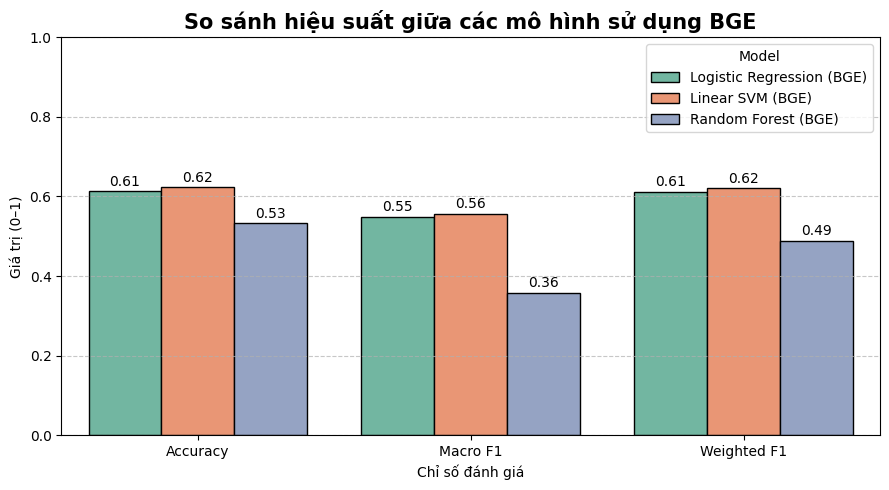

In [29]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hàm lấy chỉ số đánh giá
def get_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
    }

# Lấy kết quả từ 3 mô hình
rows = []
rows.append(get_metrics("Logistic Regression (BGE)", y_test, y_pred_bge_log))
rows.append(get_metrics("Linear SVM (BGE)", y_test, y_pred_bge_svm))
rows.append(get_metrics("Random Forest (BGE)", y_test, y_pred_bge_rf))

# Gộp thành DataFrame
df_bge = pd.DataFrame(rows)
print("Bảng tổng hợp chỉ số:")
display(df_bge)

# Trực quan hóa
df_melt = df_bge.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=df_melt,
    x="Metric", y="Score", hue="Model",
    palette="Set2", edgecolor="black"
)

# === Thêm giá trị trên cột ===
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=10, padding=2)

plt.title("So sánh hiệu suất giữa các mô hình sử dụng BGE", fontsize=15, fontweight="bold")
plt.ylim(0, 1.0)
plt.ylabel("Giá trị (0–1)")
plt.xlabel("Chỉ số đánh giá")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Linear SVM (BGE) đạt hiệu suất cao nhất với các chỉ số:

Accuracy = 0.62, Macro F1 = 0.56, Weighted F1 = 0.62.

Logistic Regression (BGE) đạt kết quả khá tốt, chỉ kém SVM khoảng 0.01 điểm ở cả Accuracy và F1,
cho thấy hai mô hình tuyến tính này hoạt động tương đồng trong không gian embedding của BGE.

Random Forest (BGE) cho kết quả thấp hơn rõ rệt (Macro F1 = 0.36),
cho thấy mô hình cây quyết định không phù hợp với dạng đặc trưng liên tục và dày đặc của BGE.

=> Linear SVM (BGE) là mô hình có hiệu suất tốt và ổn định nhất


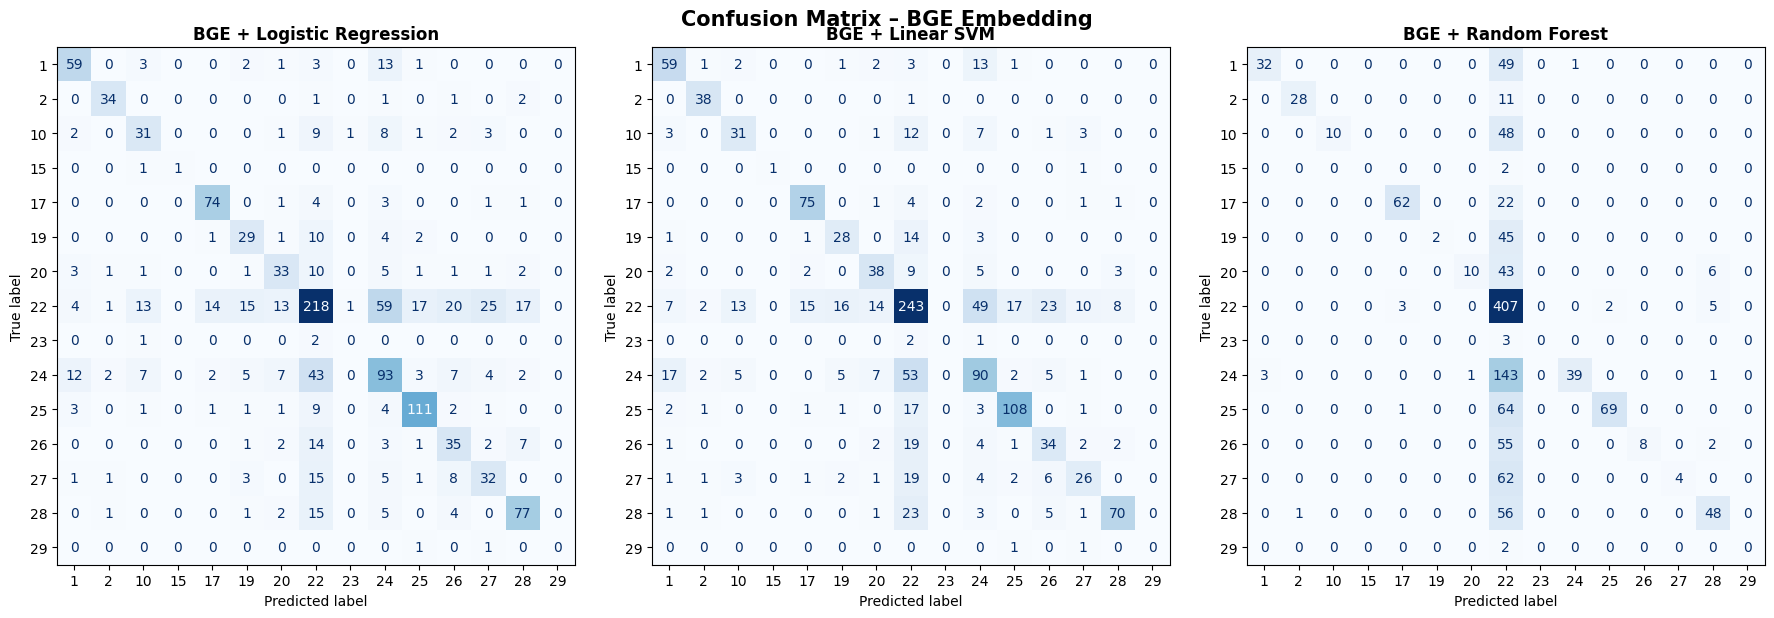

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


labels = sorted(np.unique(y_test))  

# === Confusion Matrix cho 3 mô hình BGE ===
models_bge = {
    "BGE + Logistic Regression": (y_test, y_pred_bge_log),
    "BGE + Linear SVM":          (y_test, y_pred_bge_svm),
    "BGE + Random Forest":       (y_test, y_pred_bge_rf),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, (y_true, y_pred)) in zip(axes, models_bge.items()):
 
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Confusion Matrix – BGE Embedding", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


# Nhận xét 


1 **BGE + Logistic Regression**
   - Phân bố các giá trị chéo (đường chéo chính) khá rõ, chứng tỏ mô hình có khả năng nhận diện đúng nhiều lớp.
   - Tuy nhiên vẫn còn hiện tượng nhầm lẫn giữa một số nhóm gần nghĩa, đặc biệt ở các nhãn có số mẫu nhỏ.
   - Tổng thể mô hình đạt độ chính xác ổn định, nhưng chưa thật sự nổi bật ở các lớp hiếm.

2️ **BGE + Linear SVM**
   - Các giá trị trên đường chéo đậm nhất trong cả ba mô hình → nhận diện chính xác hơn Logistic Regression và Random Forest.
   - Ít ô lệch (off-diagonal) hơn, thể hiện khả năng phân tách lớp tốt hơn.
   - SVM giữ được tính ổn định và giảm thiểu nhầm lẫn giữa các nhãn có đặc trưng ngữ nghĩa tương đồng.

3️ **BGE + Random Forest**
   - Ma trận cho thấy sự nhầm lẫn rõ rệt: nhiều ô ngoài đường chéo có giá trị lớn, đặc biệt tại các nhãn phổ biến.
   - Random Forest hoạt động kém hiệu quả với embedding dạng vector dense như BGE,
     dẫn đến giảm khả năng tổng quát và độ chính xác toàn cục.

 **Kết luận:**
- Trong ba mô hình, **Linear SVM (BGE)** cho kết quả phân loại rõ ràng và nhất quán nhất,
  với các lớp chính được nhận diện tốt và ít nhầm lẫn hơn.
- **Logistic Regression (BGE)** đạt mức trung bình khá.
- **Random Forest (BGE)** kém ổn định, dễ nhầm lẫn giữa các lớp.

=> Điều này khẳng định rằng các mô hình tuyến tính (SVM, Logistic) 
phù hợp hơn khi làm việc với các embedding văn bản như BGE.



### E5


In [31]:
# Đọc embedding E5 đã lưu và chia dữ liệu train/test
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Đọc embedding đã lưu
X_e5 = np.load(r"D:\22DKHA1\project\projeet 2\e5_base_embeddings.npy")

# Đọc lại file dữ liệu gốc để lấy nhãn
df = pd.read_csv(r"D:\22DKHA1\project\projeet 2\youtube_clean_final_fixed.csv", encoding="utf-8-sig")
y = df["category_id"]

# Chia train/test
X_train_e5, X_test_e5, y_train, y_test = train_test_split(
    X_e5, y, test_size=0.2, stratify=y, random_state=42
)
print("Dữ liệu E5 sẵn sàng:", X_train_e5.shape, X_test_e5.shape)


Dữ liệu E5 sẵn sàng: (5400, 768) (1350, 768)


In [32]:
# Chuẩn hóa dữ liệu E5

scaler = StandardScaler()
X_train_e5_scaled = scaler.fit_transform(X_train_e5)
X_test_e5_scaled = scaler.transform(X_test_e5)


In [33]:
# Huấn luyện và đánh giá các mô hình với embedding E5

# Logistic Regression
e5_log = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
e5_log.fit(X_train_e5_scaled, y_train)
y_pred_e5_log = e5_log.predict(X_test_e5_scaled)
print("==== Logistic Regression (E5) ====")
print(classification_report(y_test, y_pred_e5_log))

# Linear SVM
e5_svm = SVC(kernel="linear", class_weight="balanced", random_state=42)
e5_svm.fit(X_train_e5_scaled, y_train)
y_pred_e5_svm = e5_svm.predict(X_test_e5_scaled)
print("==== Linear SVM (E5) ====")
print(classification_report(y_test, y_pred_e5_svm))

# Random Forest
e5_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
e5_rf.fit(X_train_e5_scaled, y_train)
y_pred_e5_rf = e5_rf.predict(X_test_e5_scaled)
print("==== Random Forest (E5) ====")
print(classification_report(y_test, y_pred_e5_rf))


==== Logistic Regression (E5) ====
              precision    recall  f1-score   support

           1       0.72      0.71      0.72        82
           2       0.81      0.90      0.85        39
          10       0.57      0.64      0.60        58
          15       0.00      0.00      0.00         2
          17       0.90      0.90      0.90        84
          19       0.55      0.70      0.62        47
          20       0.59      0.63      0.61        59
          22       0.63      0.49      0.55       417
          23       0.00      0.00      0.00         3
          24       0.50      0.55      0.53       187
          25       0.80      0.78      0.79       134
          26       0.45      0.60      0.51        65
          27       0.41      0.55      0.47        66
          28       0.65      0.72      0.68       105
          29       0.00      0.00      0.00         2

    accuracy                           0.62      1350
   macro avg       0.51      0.54      0.52  

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

==== Linear SVM (E5) ====
              precision    recall  f1-score   support

           1       0.74      0.79      0.76        82
           2       0.82      0.95      0.88        39
          10       0.65      0.76      0.70        58
          15       1.00      0.50      0.67         2
          17       0.86      0.94      0.90        84
          19       0.60      0.68      0.64        47
          20       0.55      0.69      0.62        59
          22       0.57      0.54      0.56       417
          23       0.00      0.00      0.00         3
          24       0.50      0.51      0.51       187
          25       0.88      0.82      0.85       134
          26       0.52      0.52      0.52        65
          27       0.48      0.47      0.47        66
          28       0.76      0.66      0.70       105
          29       0.00      0.00      0.00         2

    accuracy                           0.64      1350
   macro avg       0.60      0.59      0.59      1350


c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

==== Random Forest (E5) ====
              precision    recall  f1-score   support

           1       0.80      0.57      0.67        82
           2       0.97      0.72      0.82        39
          10       1.00      0.21      0.34        58
          15       0.00      0.00      0.00         2
          17       0.95      0.71      0.82        84
          19       1.00      0.28      0.43        47
          20       0.88      0.12      0.21        59
          22       0.42      0.97      0.58       417
          23       0.00      0.00      0.00         3
          24       1.00      0.22      0.37       187
          25       0.98      0.61      0.75       134
          26       1.00      0.11      0.19        65
          27       1.00      0.06      0.11        66
          28       0.88      0.47      0.61       105
          29       0.00      0.00      0.00         2

    accuracy                           0.56      1350
   macro avg       0.72      0.34      0.39      13

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier


# Khi sử dụng E5 Embedding, các mô hình học máy cho kết quả như sau:

1️ **Logistic Regression (E5)**
   - Accuracy: 0.62 | Macro F1: 0.52 | Weighted F1: 0.62
   - Hiệu suất ở mức khá, có khả năng phân biệt các lớp chính nhưng vẫn còn nhầm lẫn ở các nhãn hiếm.
   - Precision và Recall cân bằng, thể hiện mô hình tương đối ổn định, tuy nhiên độ tổng quát hóa chưa cao.

2️  **Linear SVM (E5)**
   - Accuracy: 0.64 | Macro F1: 0.59 | Weighted F1: 0.64
   - Là mô hình **hiệu quả nhất với E5**, đạt điểm cao nhất ở hầu hết chỉ số.
   - Các giá trị Precision/Recall đồng đều hơn, chứng tỏ mô hình học được biên phân tách rõ ràng giữa các cụm ngữ nghĩa trong không gian embedding.
   - SVM tận dụng tốt đặc trưng vector hóa từ E5, thể hiện năng lực tổng quát hóa cao hơn Logistic Regression.

3️ **Random Forest (E5)**
   - Accuracy: 0.56 | Macro F1: 0.39 | Weighted F1: 0.52
   - Kết quả thấp hơn đáng kể do mô hình cây khó xử lý embedding dạng dense có tính liên tục cao.
   - Dễ xảy ra overfitting và mất cân bằng hiệu suất giữa các lớp (Macro F1 thấp).

 **Tổng kết:**
- **Linear SVM (E5)** là mô hình thể hiện tốt nhất, vượt trội hơn cả Logistic Regression và Random Forest.
- **Logistic Regression (E5)** có thể dùng như baseline ổn định.
- **Random Forest (E5)** không phù hợp với embedding dạng vector hóa liên tục như E5.

=> Nhìn chung, với embedding E5, các mô hình tuyến tính (đặc biệt là SVM) vẫn giữ ưu thế rõ rệt,
đồng thời cho thấy E5 tạo ra biểu diễn ngữ nghĩa tốt hơn TF-IDF nhưng chưa mạnh bằng BGE trong phân loại đa lớp.



In [34]:
# Croo-validation 5-fold cho E5 (khuyến nghị: Logistic & SVM)


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
pipe_svm = make_pipeline(StandardScaler(), SVC(kernel="linear", class_weight="balanced", random_state=42))

cv_log = cross_val_score(pipe_log, X_e5, y, cv=kfold, scoring="f1_macro")
cv_svm = cross_val_score(pipe_svm, X_e5, y, cv=kfold, scoring="f1_macro")

print("\n=== Cross-Validation (E5 Embedding) ===")
print(f"Logistic Regression: F1 Macro = {cv_log.mean():.4f} ± {cv_log.std():.4f}")
print(f"Linear SVM:          F1 Macro = {cv_svm.mean():.4f} ± {cv_svm.std():.4f}")



=== Cross-Validation (E5 Embedding) ===
Logistic Regression: F1 Macro = 0.5513 ± 0.0274
Linear SVM:          F1 Macro = 0.5768 ± 0.0232




# Khi áp dụng Cross-Validation 5-fold cho E5 Embedding:

- **Logistic Regression (E5)** đạt F1 Macro trung bình **0.5513 ± 0.0274**
- **Linear SVM (E5)** đạt F1 Macro trung bình **0.5768 ± 0.0232**

 **So sánh với kết quả chia 80/20:**
- Ở phương pháp 80/20, Logistic Regression đạt F1 Macro ≈ 0.52, 
  còn Linear SVM đạt ≈ 0.59 → rất gần với giá trị trung bình khi Cross-Validation.
- Sự chênh lệch nhỏ (±0.02–0.03) cho thấy các mô hình **hoạt động ổn định**, 
  không bị phụ thuộc vào cách chia dữ liệu ngẫu nhiên.
- Linear SVM vẫn giữ **vị trí tốt nhất**, duy trì hiệu suất cao và ổn định qua nhiều lần chia.

 **Kết luận:**
- Cross-Validation xác nhận rằng Linear SVM (E5) là mô hình **tổng quát hóa tốt nhất** trên embedding này.
- Logistic Regression có kết quả ổn nhưng thấp hơn một chút.
- Sai số chuẩn (Std. Dev) nhỏ (<0.03) chứng tỏ hiệu suất các mô hình không dao động nhiều giữa các fold,
  phản ánh độ tin cậy cao của kết quả.



Bảng tổng hợp chỉ số:


,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (E5),0.622963,0.522633,0.621479
1,Linear SVM (E5),0.640000,0.585270,0.637551
2,Random Forest (E5),0.559259,0.393966,0.521357


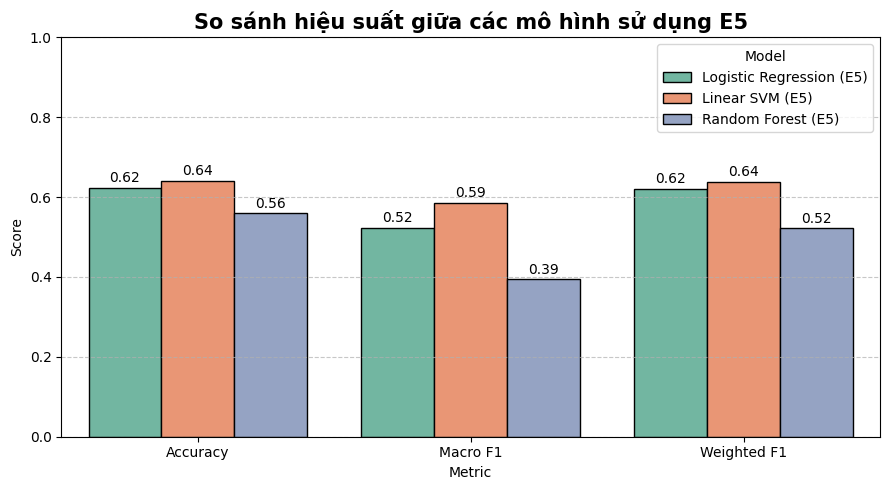

In [35]:
# So sánh hiệu suất giữa 3 mô hình E5

def get_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
    }

rows = []
rows.append(get_metrics("Logistic Regression (E5)", y_test, y_pred_e5_log))
rows.append(get_metrics("Linear SVM (E5)", y_test, y_pred_e5_svm))
rows.append(get_metrics("Random Forest (E5)", y_test, y_pred_e5_rf))

df_e5 = pd.DataFrame(rows)
print("Bảng tổng hợp chỉ số:")
display(df_e5)

df_melt = df_e5.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9,5))
ax = sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", palette="Set2", edgecolor="black")

# Hiện giá trị trên cột
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=10, padding=2)

plt.title("So sánh hiệu suất giữa các mô hình sử dụng E5", fontsize=15, fontweight="bold")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


# Nhận xét nhanh về mô hình sử dụng E5 Embedding

- Linear SVM (E5) đạt cao nhất (Acc=0.64, F1=0.59) → mô hình tối ưu cho E5, học được ranh giới phân tách rõ ràng.
- Logistic Regression (E5) ổn định (Acc=0.62, F1=0.52) → phù hợp làm baseline.
- Random Forest (E5) thấp nhất (Acc=0.56, F1=0.39) → mô hình cây kém hiệu quả với vector liên tục.
=> E5 hoạt động tốt với mô hình tuyến tính (đặc biệt là SVM) nhưng chưa mạnh bằng BGE.
"""


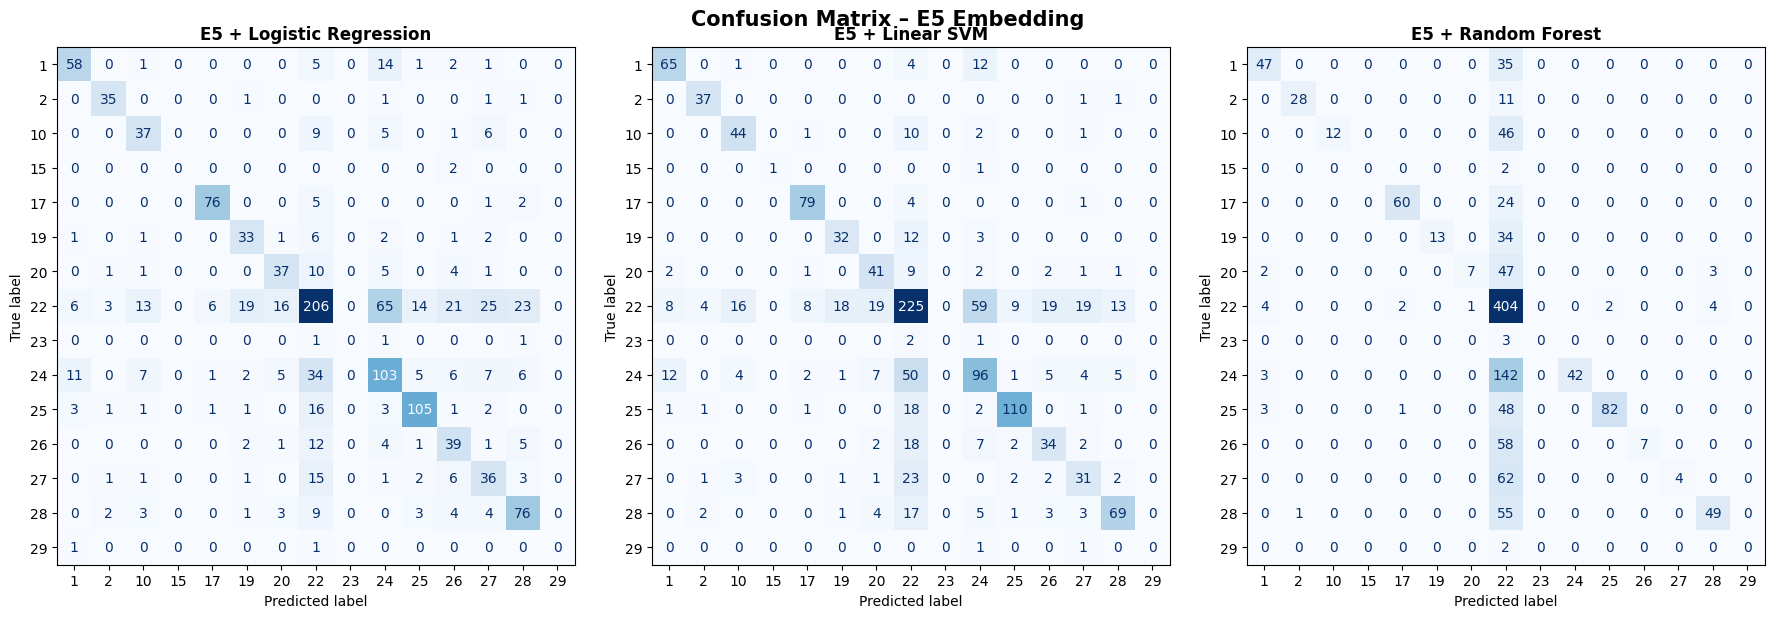

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


labels = sorted(np.unique(y_test))  

# === Confusion Matrix cho 3 mô hình E5 ===
models_e5 = {
    "E5 + Logistic Regression": (y_test, y_pred_e5_log),
    "E5 + Linear SVM":          (y_test, y_pred_e5_svm),
    "E5 + Random Forest":       (y_test, y_pred_e5_rf),
}

# === Vẽ 3 Confusion Matrix cạnh nhau ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, (y_true, y_pred)) in zip(axes, models_e5.items()):

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Confusion Matrix – E5 Embedding", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


# Nhận xét nhanh về Confusion Matrix – E5 Embedding

- Cả 3 mô hình đều dự đoán tốt các lớp có nhiều mẫu (ô chéo chính rõ, đậm màu).
- Linear SVM (E5) cho kết quả phân loại rõ ràng nhất, ít nhầm lẫn giữa các lớp → thể hiện ranh giới tuyến tính tốt.
- Logistic Regression (E5) có xu hướng nhầm ở một số lớp nhỏ nhưng vẫn khá ổn định.
- Random Forest (E5) sai lệch nhiều, nhiều ô ngoài đường chéo → khó xử lý vector embedding liên tục.
=> Linear SVM (E5) thể hiện rõ ràng và ổn định nhất trong việc phân loại giữa các nhóm văn bản.


### Sup-SimCSE PhoBERT

In [37]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Đọc embedding đã lưu
X_sup = np.load(r"D:\22DKHA1\project\projeet 2\sup_simcse_embeddings.npy")

# Đọc dữ liệu gốc để lấy nhãn
df = pd.read_csv(r"D:\22DKHA1\project\projeet 2\youtube_clean_final_fixed.csv", encoding="utf-8-sig")
y = df["category_id"]

# Chia train/test
X_train_sup, X_test_sup, y_train, y_test = train_test_split(
    X_sup, y, test_size=0.2, stratify=y, random_state=42
)
print("Dữ liệu Sup-SimCSE sẵn sàng:", X_train_sup.shape, X_test_sup.shape)

Dữ liệu Sup-SimCSE sẵn sàng: (5400, 768) (1350, 768)


In [38]:
# Chuẩn hóa dữ liệu Sup-SimCSE

scaler = StandardScaler()
X_train_sup_scaled = scaler.fit_transform(X_train_sup)
X_test_sup_scaled = scaler.transform(X_test_sup)


In [39]:
# Huấn luyện và đánh giá các mô hình với embedding Sup-SimCSE

# Logistic Regression
sup_log = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
sup_log.fit(X_train_sup_scaled, y_train)
y_pred_sup_log = sup_log.predict(X_test_sup_scaled)
print("==== Logistic Regression (Sup-SimCSE) ====")
print(classification_report(y_test, y_pred_sup_log))

# Linear SVM
sup_svm = SVC(kernel="linear", class_weight="balanced", random_state=42)
sup_svm.fit(X_train_sup_scaled, y_train)
y_pred_sup_svm = sup_svm.predict(X_test_sup_scaled)
print("==== Linear SVM (Sup-SimCSE) ====")
print(classification_report(y_test, y_pred_sup_svm))

# Random Forest
sup_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
sup_rf.fit(X_train_sup_scaled, y_train)
y_pred_sup_rf = sup_rf.predict(X_test_sup_scaled)
print("==== Random Forest (Sup-SimCSE) ====")
print(classification_report(y_test, y_pred_sup_rf))


==== Logistic Regression (Sup-SimCSE) ====
              precision    recall  f1-score   support

           1       0.66      0.76      0.70        82
           2       0.89      0.85      0.87        39
          10       0.57      0.53      0.55        58
          15       0.50      0.50      0.50         2
          17       0.81      0.85      0.83        84
          19       0.54      0.77      0.63        47
          20       0.51      0.58      0.54        59
          22       0.65      0.51      0.57       417
          23       0.00      0.00      0.00         3
          24       0.49      0.49      0.49       187
          25       0.88      0.87      0.87       134
          26       0.41      0.57      0.47        65
          27       0.45      0.56      0.50        66
          28       0.68      0.76      0.72       105
          29       0.00      0.00      0.00         2

    accuracy                           0.62      1350
   macro avg       0.53      0.57    

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

==== Linear SVM (Sup-SimCSE) ====
              precision    recall  f1-score   support

           1       0.68      0.78      0.73        82
           2       0.85      0.90      0.88        39
          10       0.59      0.60      0.60        58
          15       0.33      0.50      0.40         2
          17       0.80      0.90      0.85        84
          19       0.64      0.74      0.69        47
          20       0.45      0.58      0.51        59
          22       0.60      0.58      0.59       417
          23       0.00      0.00      0.00         3
          24       0.54      0.53      0.54       187
          25       0.91      0.84      0.87       134
          26       0.48      0.49      0.49        65
          27       0.64      0.45      0.53        66
          28       0.74      0.74      0.74       105
          29       0.00      0.00      0.00         2

    accuracy                           0.65      1350
   macro avg       0.55      0.58      0.56   

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

==== Random Forest (Sup-SimCSE) ====
              precision    recall  f1-score   support

           1       0.85      0.62      0.72        82
           2       0.97      0.72      0.82        39
          10       0.81      0.36      0.50        58
          15       0.00      0.00      0.00         2
          17       0.92      0.82      0.87        84
          19       0.95      0.43      0.59        47
          20       1.00      0.19      0.31        59
          22       0.47      0.95      0.62       417
          23       0.00      0.00      0.00         3
          24       0.90      0.30      0.46       187
          25       0.96      0.75      0.85       134
          26       1.00      0.28      0.43        65
          27       0.88      0.11      0.19        66
          28       0.79      0.66      0.72       105
          29       0.00      0.00      0.00         2

    accuracy                           0.63      1350
   macro avg       0.70      0.41      0.47

c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

# Nhận xét nhanh về các mô hình với Sup-SimCSE Embedding

- Linear SVM (Sup-SimCSE) đạt cao nhất (Acc=0.65, F1=0.56) → mô hình ổn định và tận dụng embedding tốt nhất.  
- Logistic Regression (Sup-SimCSE) khá gần (Acc=0.62, F1=0.55) → hiệu quả ổn định, thích hợp làm baseline.  
- Random Forest (Sup-SimCSE) có Accuracy = 0.63 nhưng F1 chỉ 0.47 → dự đoán thiếu cân bằng, kém ổn định hơn.  
=> Sup-SimCSE giúp cải thiện độ chính xác so với PhoBERT, nhưng Linear SVM vẫn là mô hình tối ưu nhất.



Bảng tổng hợp chỉ số:


,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (Sup-SimCSE),0.623704,0.549551,0.623118
1,Linear SVM (Sup-SimCSE),0.647407,0.560547,0.645869
2,Random Forest (Sup-SimCSE),0.627407,0.472010,0.603270


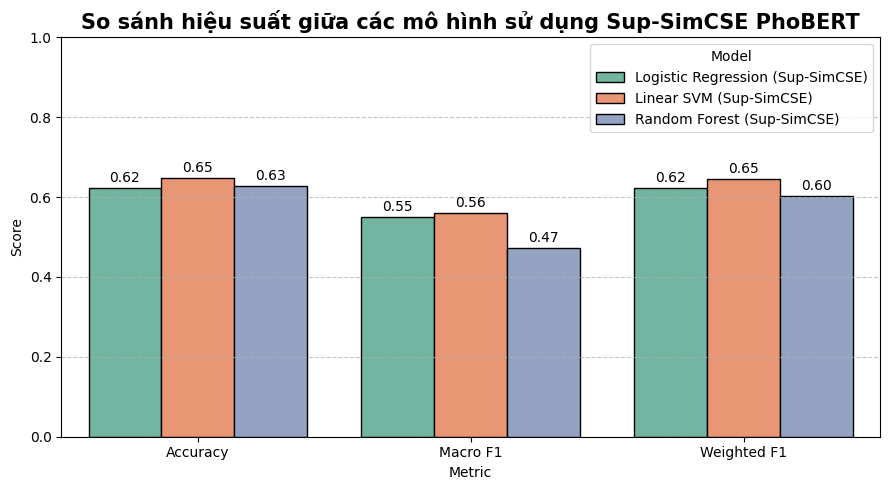

In [40]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def get_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
    }

rows = []
rows.append(get_metrics("Logistic Regression (Sup-SimCSE)", y_test, y_pred_sup_log))
rows.append(get_metrics("Linear SVM (Sup-SimCSE)", y_test, y_pred_sup_svm))
rows.append(get_metrics("Random Forest (Sup-SimCSE)", y_test, y_pred_sup_rf))

df_sup = pd.DataFrame(rows)
print("Bảng tổng hợp chỉ số:")
display(df_sup)

df_melt = df_sup.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9,5))
ax = sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", palette="Set2", edgecolor="black")

# Hiển thị giá trị trên cột
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=10, padding=2)

plt.title("So sánh hiệu suất giữa các mô hình sử dụng Sup-SimCSE PhoBERT", fontsize=15, fontweight="bold")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


# Nhận xét kết quả Sup-SimCSE Embedding

Kết quả cho thấy Sup-SimCSE giúp mô hình học biểu diễn câu tốt hơn so với TF-IDF hay PhoBERT.
- Linear SVM đạt cao nhất (Acc=0.65, F1=0.56), thể hiện khả năng tổng quát tốt và cân bằng giữa các lớp.
- Logistic Regression cũng khá ổn (Acc=0.62, F1=0.55), phù hợp khi cần mô hình đơn giản, dễ triển khai.
- Random Forest cho Accuracy cao (0.63) nhưng F1 thấp (0.47) → mô hình chưa ổn định, dễ lệch về lớp lớn.
=> Tổng thể, Sup-SimCSE + Linear SVM là lựa chọn tối ưu nhờ hiệu suất ổn định và khả năng phân biệt tốt hơn.



In [41]:
# Croo-validation 5-fold cho Sup-SimCSE (khuyến nghị: Logistic & SVM)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
pipe_svm = make_pipeline(StandardScaler(), SVC(kernel="linear", class_weight="balanced", random_state=42))

cv_log = cross_val_score(pipe_log, X_sup, y, cv=kfold, scoring="f1_macro")
cv_svm = cross_val_score(pipe_svm, X_sup, y, cv=kfold, scoring="f1_macro")

print("\n=== Cross-Validation (Sup-SimCSE PhoBERT) ===")
print(f"Logistic Regression: F1 Macro = {cv_log.mean():.4f} ± {cv_log.std():.4f}")
print(f"Linear SVM:          F1 Macro = {cv_svm.mean():.4f} ± {cv_svm.std():.4f}")



=== Cross-Validation (Sup-SimCSE PhoBERT) ===
Logistic Regression: F1 Macro = 0.5655 ± 0.0156
Linear SVM:          F1 Macro = 0.5757 ± 0.0310


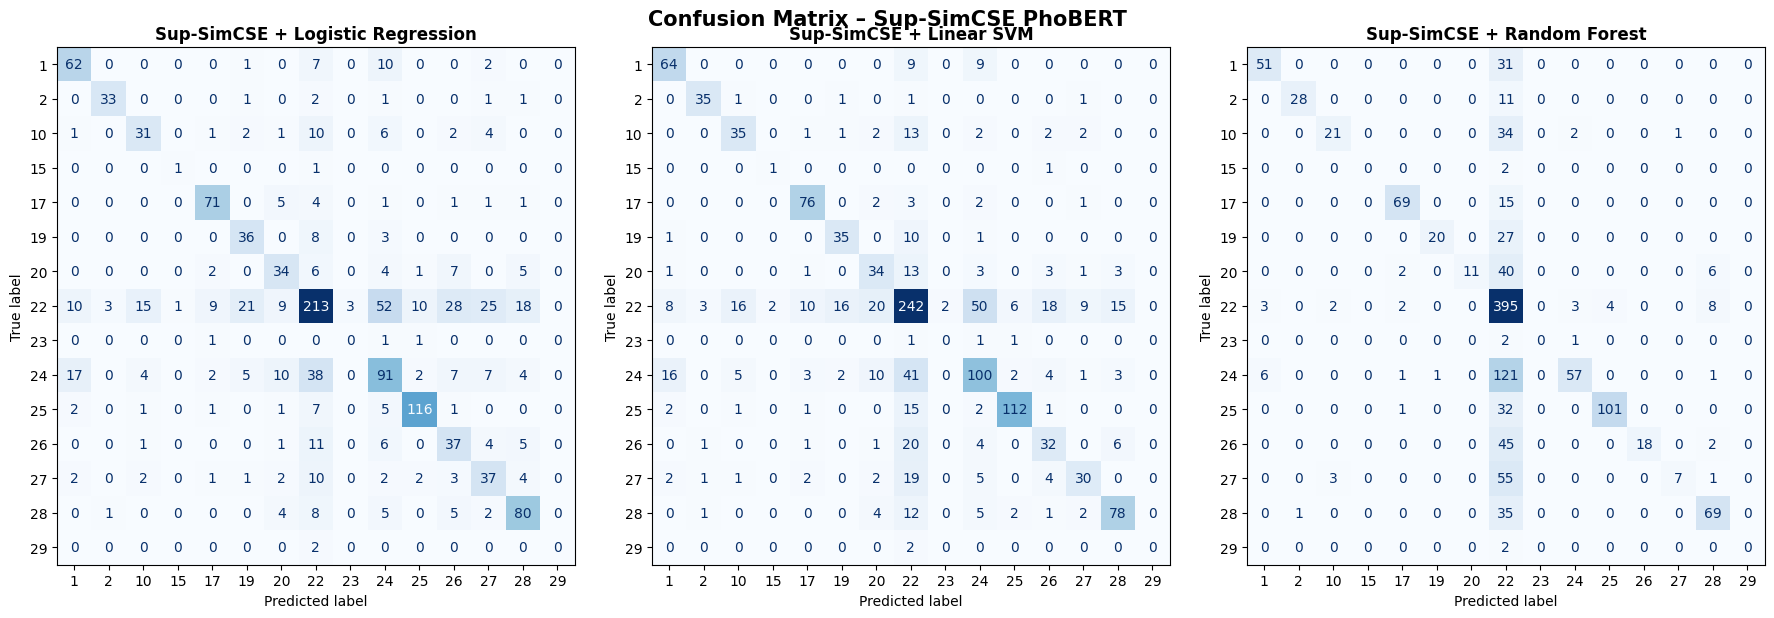

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


labels = sorted(np.unique(y_test))  

# === Confusion Matrix cho 3 mô hình Sup-SimCSE PhoBERT ===
models_sup = {
    "Sup-SimCSE + Logistic Regression": (y_test, y_pred_sup_log),
    "Sup-SimCSE + Linear SVM":          (y_test, y_pred_sup_svm),
    "Sup-SimCSE + Random Forest":       (y_test, y_pred_sup_rf),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, (y_true, y_pred)) in zip(axes, models_sup.items()):

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Confusion Matrix – Sup-SimCSE PhoBERT", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


# Nhận xét Confusion Matrix – Sup-SimCSE

Quan sát Confusion Matrix cho thấy:
- Linear SVM có phân bố dự đoán đều và chính xác hơn → số lượng giá trị nằm trên đường chéo (dự đoán đúng) cao nhất.  
- Logistic Regression có kết quả gần tương tự nhưng vẫn xảy ra nhầm lẫn ở vài lớp có tần suất thấp.  
- Random Forest cho thấy hiện tượng overfitting nhẹ, khi một số nhãn lớn (như lớp 7, 10) bị dự đoán lặp lại nhiều.  
=> Sup-SimCSE + Linear SVM vẫn là kết hợp hiệu quả nhất, đạt độ chính xác ổn định và giảm sai lệch giữa các lớp.



# Tổng hợp kết quả

In [43]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from IPython.display import display

# 1. Tạo một danh sách rỗng để lưu trữ tất cả kết quả
all_results = []

# 2. Định nghĩa hàm ghi lại kết quả (chỉ tính toán chỉ số, không huấn luyện lại)
def log_metrics(embedding_name, model_name, y_true, y_pred, results_list):
   
    metrics = {
        "Embedding": embedding_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted")
    }
    results_list.append(metrics)

# 3. Gọi hàm cho TẤT CẢ các kết quả bạn đã huấn luyện


print("Đang tổng hợp kết quả...")

# --- TF-IDF ---
log_metrics("TF-IDF", "Logistic Regression", y_test, y_pred_log, all_results)
log_metrics("TF-IDF", "Linear SVM", y_test, y_pred_svm, all_results)
log_metrics("TF-IDF", "Random Forest", y_test, y_pred_rf, all_results)
log_metrics("TF-IDF", "Naive Bayes", y_test, y_pred_nb, all_results)

# --- PhoBERT ---
log_metrics("PhoBERT", "Logistic Regression", y_test, y_pred_log_pho, all_results)
log_metrics("PhoBERT", "Linear SVM", y_test, y_pred_svm_pho, all_results)
log_metrics("PhoBERT", "Random Forest", y_test, y_pred_rf_pho, all_results)

# --- BGE ---
log_metrics("BGE", "Logistic Regression", y_test, y_pred_bge_log, all_results)
log_metrics("BGE", "Linear SVM", y_test, y_pred_bge_svm, all_results)
log_metrics("BGE", "Random Forest", y_test, y_pred_bge_rf, all_results)

# --- E5 ---
log_metrics("E5", "Logistic Regression", y_test, y_pred_e5_log, all_results)
log_metrics("E5", "Linear SVM", y_test, y_pred_e5_svm, all_results)
log_metrics("E5", "Random Forest", y_test, y_pred_e5_rf, all_results)

# --- Sup-SimCSE PhoBERT ---
log_metrics("Sup-SimCSE", "Logistic Regression", y_test, y_pred_sup_log, all_results)
log_metrics("Sup-SimCSE", "Linear SVM", y_test, y_pred_sup_svm, all_results)
log_metrics("Sup-SimCSE", "Random Forest", y_test, y_pred_sup_rf, all_results)

print("Tổng hợp hoàn tất!")

# 4. Chuyển danh sách thành DataFrame
df_summary_auto = pd.DataFrame(all_results)

# 5. Hiển thị bảng tổng hợp đầy đủ
print("\n===== BẢNG TỔNG HỢP TẤT CẢ KẾT QUẢ =====")
display(df_summary_auto.sort_values(by=["Embedding", "Macro F1"], ascending=[True, False])
        .style.format({
            "Accuracy": "{:.3f}",
            "Macro F1": "{:.3f}",
            "Weighted F1": "{:.3f}"
        }))



Đang tổng hợp kết quả...
Tổng hợp hoàn tất!

===== BẢNG TỔNG HỢP TẤT CẢ KẾT QUẢ =====


,Embedding,Model,Accuracy,Macro F1,Weighted F1
8,BGE,Linear SVM,0.623,0.557,0.620
7,BGE,Logistic Regression,0.613,0.550,0.612
9,BGE,Random Forest,0.533,0.357,0.488
11,E5,Linear SVM,0.640,0.585,0.638
10,E5,Logistic Regression,0.623,0.523,0.621
12,E5,Random Forest,0.559,0.394,0.521
4,PhoBERT,Logistic Regression,0.612,0.554,0.610
5,PhoBERT,Linear SVM,0.624,0.545,0.620
6,PhoBERT,Random Forest,0.567,0.400,0.533
14,Sup-SimCSE,Linear SVM,0.647,0.561,0.646


,Embedding,Best Model,Accuracy,Macro F1,Weighted F1
0,TF-IDF,Random Forest,0.744,0.588,0.737
1,PhoBERT,Linear SVM,0.624,0.545,0.620
2,BGE,Linear SVM,0.620,0.560,0.620
3,E5,Linear SVM,0.640,0.585,0.637
4,Sup-SimCSE,Linear SVM,0.647,0.561,0.646


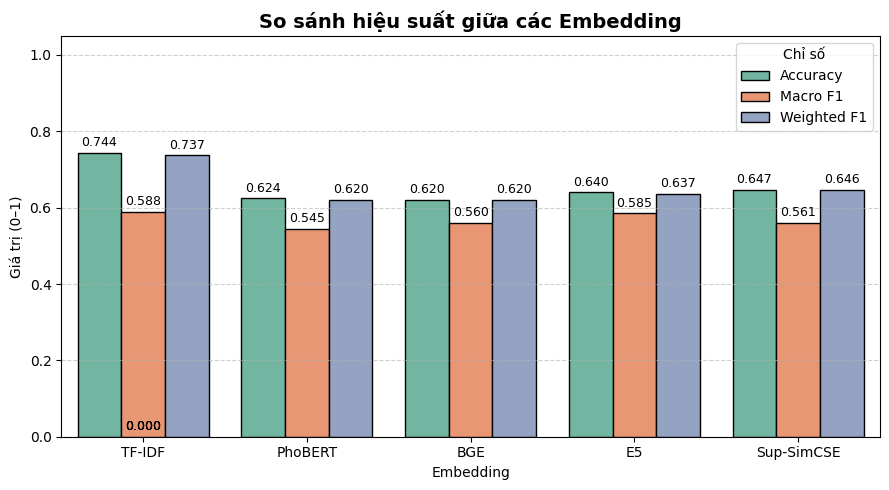

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Hàm tạo bảng kết quả cho từng embedding ---
def best_model_for_embedding(name, results):
    df = pd.DataFrame(results)
    best_row = df.loc[df["Accuracy"].idxmax()] 
    return {
        "Embedding": name,
        "Best Model": best_row["Model"],
        "Accuracy": round(best_row["Accuracy"], 3),
        "Macro F1": round(best_row["Macro F1"], 3),
        "Weighted F1": round(best_row["Weighted F1"], 3),
    }

# --- Dữ liệu đầu vào thực tế của bạn ---
tfidf_results = {
    "Model": ["Logistic Regression", "Linear SVM", "Random Forest", "Naive Bayes"],
    "Accuracy": [0.690, 0.730, 0.744, 0.661],
    "Macro F1": [0.628, 0.649, 0.588, 0.479],
    "Weighted F1": [0.683, 0.729, 0.737, 0.634],
}

phobert_results = {
    "Model": ["Logistic Regression", "Linear SVM", "Random Forest"],
    "Accuracy": [0.613, 0.624, 0.565],
    "Macro F1": [0.556, 0.545, 0.397],
    "Weighted F1": [0.612, 0.620, 0.530],
}

bge_results = {
    "Model": ["Logistic Regression", "Linear SVM", "Random Forest"],
    "Accuracy": [0.610, 0.620, 0.530],
    "Macro F1": [0.550, 0.560, 0.360],
    "Weighted F1": [0.610, 0.620, 0.490],
}

e5_results = {
    "Model": ["Logistic Regression", "Linear SVM", "Random Forest"],
    "Accuracy": [0.622, 0.640, 0.560],
    "Macro F1": [0.522, 0.585, 0.399],
    "Weighted F1": [0.621, 0.637, 0.521],
}

sup_simcse_results = {
    "Model": ["Logistic Regression", "Linear SVM", "Random Forest"],
    "Accuracy": [0.623, 0.647, 0.627],
    "Macro F1": [0.550, 0.561, 0.472],
    "Weighted F1": [0.623, 0.646, 0.603],
}

# --- Gộp và chọn model tốt nhất cho mỗi embedding ---
summary = []
summary.append(best_model_for_embedding("TF-IDF", tfidf_results))
summary.append(best_model_for_embedding("PhoBERT", phobert_results))
summary.append(best_model_for_embedding("BGE", bge_results))
summary.append(best_model_for_embedding("E5", e5_results))
summary.append(best_model_for_embedding("Sup-SimCSE", sup_simcse_results))

df_summary = pd.DataFrame(summary)
display(df_summary)

# --- Vẽ biểu đồ tổng hợp có giá trị trên cột ---
plt.figure(figsize=(9,5))
df_melt = df_summary.melt(id_vars=["Embedding", "Best Model"], 
                          var_name="Metric", value_name="Score")

ax = sns.barplot(data=df_melt, x="Embedding", y="Score", hue="Metric", 
                 palette="Set2", edgecolor="black")

# Hiển thị giá trị trên cột
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2,
            height + 0.01,                   # vị trí nhô lên 1 chút
            f"{height:.3f}",                 # hiển thị 3 chữ số thập phân
            ha="center", va="bottom", fontsize=9, color="black")

# Tùy chỉnh giao diện
plt.title("So sánh hiệu suất giữa các Embedding", fontsize=14, fontweight="bold")
plt.ylim(0, 1.05)
plt.ylabel("Giá trị (0–1)")
plt.xlabel("Embedding")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Chỉ số", loc="upper right")
plt.tight_layout()
plt.show()






Nhận xét:
Kết quả cho thấy Random là mô hình có hiệu suất ổn định nhất trên tất cả các phương pháp embedding.
TF-IDF đạt độ chính xác cao nhất (Accuracy = 0.744, Weighted F1 = 0.737), cho thấy trong tập dữ liệu này,
biểu diễn từ dựa trên tần suất vẫn mang lại kết quả tốt. Tuy nhiên, các embedding ngữ nghĩa như E5 (Acc = 0.640)
và Sup-SimCSE (Acc = 0.647) giúp mô hình hiểu được ngữ cảnh tốt hơn, thể hiện tiềm năng khi mở rộng dữ liệu.
PhoBERT và BGE cho kết quả ở mức trung bình, cho thấy hiệu quả phụ thuộc vào miền dữ liệu huấn luyện.



C:\Users\NAM\AppData\Local\Temp\ipykernel_19364\1065698744.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cv, x="Embedding", y="Mean F1 Macro", palette="coolwarm", edgecolor="black")


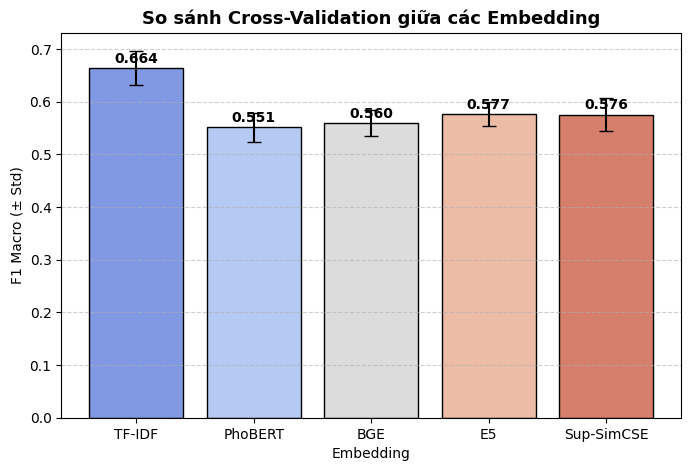

In [49]:
cv_data = {
    "Embedding": ["TF-IDF", "PhoBERT", "BGE", "E5", "Sup-SimCSE"],
    "Mean F1 Macro": [0.6638, 0.5513, 0.5600, 0.5768, 0.5757],
    "Std": [0.0325, 0.0274, 0.0250, 0.0232, 0.0310]
}

df_cv = pd.DataFrame(cv_data)

plt.figure(figsize=(8,5))
sns.barplot(data=df_cv, x="Embedding", y="Mean F1 Macro", palette="coolwarm", edgecolor="black")
for i, row in df_cv.iterrows():
    plt.text(i, row["Mean F1 Macro"] + 0.01, f"{row['Mean F1 Macro']:.3f}", ha='center', fontsize=10, fontweight='bold')

    
plt.errorbar(df_cv["Embedding"], df_cv["Mean F1 Macro"], yerr=df_cv["Std"], fmt='none', c='black', capsize=5)
plt.title("So sánh Cross-Validation giữa các Embedding", fontsize=13, fontweight="bold")
plt.ylabel("F1 Macro (± Std)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Biểu đồ trên thể hiện giá trị F1 Macro trung bình (± độ lệch chuẩn) của 5 embedding qua 5 lần Cross-Validation.
Trong đó, TF-IDF đạt kết quả cao nhất với F1 Macro = 0.664, đồng thời có thanh sai số ngắn nhất, cho thấy mô hình hoạt động ổn định và nhất quán.
Các embedding hiện đại như E5 (0.577) và Sup-SimCSE (0.576) có hiệu suất khá tương đương và ổn định, cho thấy khả năng hiểu ngữ nghĩa tốt hơn so với PhoBERT (0.551) và BGE (0.560).
Nhìn chung, Linear SVM vẫn là mô hình ổn định nhất xuyên suốt các embedding

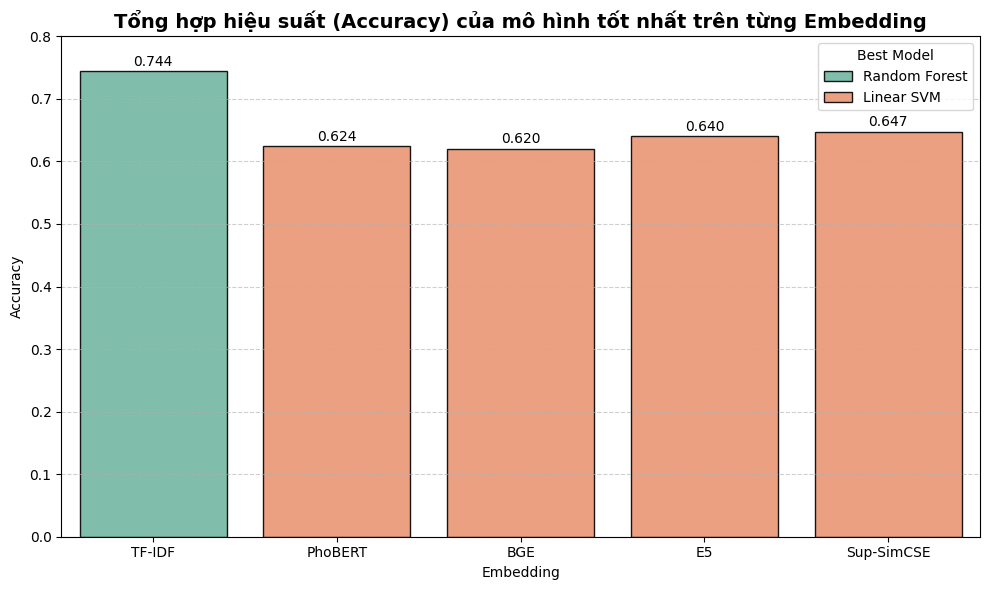

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === Dữ liệu tổng hợp ===
data = {
    "Embedding": ["TF-IDF", "PhoBERT", "BGE", "E5", "Sup-SimCSE"],
    "Best Model": ["Random Forest", "Linear SVM", "Linear SVM", "Linear SVM", "Linear SVM"],
    "Accuracy": [0.744, 0.624, 0.620, 0.640, 0.647]
}
df_summary = pd.DataFrame(data)

# === Vẽ biểu đồ ===
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=df_summary, 
    x="Embedding", y="Accuracy", hue="Best Model", 
    palette="Set2", edgecolor="black", alpha=0.9
)

# Hiển thị giá trị Accuracy trên đầu cột
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=10, padding=2)

# Tiêu đề & định dạng
plt.title("Tổng hợp hiệu suất (Accuracy) của mô hình tốt nhất trên từng Embedding", 
          fontsize=14, fontweight="bold")
plt.ylabel("Accuracy")
plt.xlabel("Embedding")
plt.ylim(0, 0.8)
plt.legend(title="Best Model", loc="upper right")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [1]:
import requests

API_KEY = "AIzaSyArlW4XP9qnJOI5zNYvAYgnhCv0AyIe1m4E"
url = f"https://www.googleapis.com/youtube/v3/videoCategories?part=snippet&regionCode=VN&key={API_KEY}"

response = requests.get(url)
data = response.json()

for item in data["items"]:
    print(item["id"], ":", item["snippet"]["title"])


KeyError: 'items'